# Phase 2 -- Meta-analysis and Network Analysis with MUUMI

**Project:** Computational pipeline for the identification of molecular targets in ischemia-reperfusion acute kidney injury (IR-AKI)  
**Input:** Phase 1 outputs (per-dataset DE gene-level results)  
**Main tool:** [MUUMI](https://github.com/fhaive/muumi) (Inkala et al., BMC Bioinformatics, 2026)  

**Datasets:**  
- **Cat. A** (IRI vs Control): GSE43974 (microarray, n=206), GSE142077 (RNA-seq, n=10), GSE126805 (RNA-seq, n=83)  
- **Cat. B** (Validation, DGF vs IGF): GSE54888 (microarray, n=54)  

---

### Notebook structure

1. **Setup and data loading**  
2. **Statistical meta-analysis** -- Ensemble meta-analysis (MUUMI Module 1)  
3. **GSEA and seed gene selection** -- Feature selection with |log2FC| > 0.379  
4. **Cat. B validation** -- Independent confirmation on GSE54888  
5. **Co-expression networks** -- Network inference (MUUMI Module 2)  
6. **Cross-platform late integration** -- NMF module aggregation (MUUMI Module 3)  
7. **ESEA** -- Edge Set Enrichment Analysis (MUUMI Module 4)  
8. **PPI** -- Protein Protein Intraction network analysis (STRINGdb)
8. **Summary**

## 1. Setup and data loading

In [1]:
# ============================================================
# 1.1  Libraries
# ============================================================
suppressPackageStartupMessages({
  library(muumi)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(clusterProfiler)
  library(ReactomePA)
  library(org.Hs.eg.db)
  library(fgsea)
  library(igraph)
})

set.seed(0)
theme_set(theme_bw(base_size = 12))

In [2]:
# ============================================================
# 1.2  Paths -- ADJUST to your folder structure
# ============================================================
BASE_DIR   <- ".."
FASE1_DIR  <- file.path(BASE_DIR, "output", "fase1")
OUT_DIR    <- file.path(BASE_DIR, "output", "fase2")
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

# Cat. A datasets (IRI vs Control)
cat_a_files <- c(
  GSE43974  = file.path(FASE1_DIR, "GSE43974",  "de_GSE43974_IRI_vs_Control.csv"),
  GSE142077 = file.path(FASE1_DIR, "GSE142077", "de_GSE142077_IRI_vs_Control.csv"),
  GSE126805 = file.path(FASE1_DIR, "GSE126805", "de_GSE126805_IRI_vs_Control.csv")
)

# Cat. B dataset (DGF vs IGF -- validation)
cat_b_files <- c(
  GSE54888 = file.path(FASE1_DIR, "GSE54888", "de_GSE54888_DGF_vs_IGF.csv")
)

# Expression matrices (for network analysis)
expr_files <- c(
  GSE43974  = file.path(FASE1_DIR, "GSE43974",  "expr_GSE43974.csv"),
  GSE142077 = file.path(FASE1_DIR, "GSE142077", "expr_GSE142077.csv.gz"),
  GSE126805 = file.path(FASE1_DIR, "GSE126805", "expr_GSE126805.csv.gz")
)

# Sample labels
label_files <- c(
  GSE43974  = file.path(FASE1_DIR, "GSE43974",  "sample_labels_GSE43974.csv"),
  GSE142077 = file.path(FASE1_DIR, "GSE142077", "sample_labels_GSE142077.csv"),
  GSE126805 = file.path(FASE1_DIR, "GSE126805", "sample_labels_GSE126805.csv")
)

In [3]:
# ============================================================
# 1.3  Load Phase 1 DE results
# ============================================================
load_de <- function(path, dataset_id) {
  df <- read.csv(path, stringsAsFactors = FALSE)
  df$dataset <- dataset_id
  df
}

de_cat_a <- lapply(names(cat_a_files), function(id) load_de(cat_a_files[id], id))
names(de_cat_a) <- names(cat_a_files)

de_cat_b <- lapply(names(cat_b_files), function(id) load_de(cat_b_files[id], id))
names(de_cat_b) <- names(cat_b_files)

cat("== Cat. A dataset summary ==\n")
for (nm in names(de_cat_a)) {
  d <- de_cat_a[[nm]]
  n_sig <- sum(d$padj < 0.05 & abs(d$log2FoldChange) > 0.379, na.rm = TRUE)
  cat(sprintf("  %s: %d total genes, %d DEG (|log2FC|>0.379, FDR<0.05)\n", nm, nrow(d), n_sig))
}
cat("\n== Cat. B dataset summary ==\n")
for (nm in names(de_cat_b)) {
  d <- de_cat_b[[nm]]
  n_sig <- sum(d$padj < 0.05 & abs(d$log2FoldChange) > 0.379, na.rm = TRUE)
  cat(sprintf("  %s: %d total genes, %d DEG\n", nm, nrow(d), n_sig))
}

== Cat. A dataset summary ==
  GSE43974: 28794 total genes, 1269 DEG (|log2FC|>0.379, FDR<0.05)
  GSE142077: 25221 total genes, 644 DEG (|log2FC|>0.379, FDR<0.05)
  GSE126805: 18832 total genes, 1177 DEG (|log2FC|>0.379, FDR<0.05)

== Cat. B dataset summary ==
  GSE54888: 23307 total genes, 0 DEG


## 2. Statistical meta-analysis (MUUMI Module 1)

In [4]:
# ============================================================
# 2.1  Build adjusted p-value matrix across datasets
# ============================================================
padj_list <- lapply(names(de_cat_a), function(id) {
  d <- de_cat_a[[id]] %>%
    dplyr::select(gene, padj) %>%
    dplyr::filter(!is.na(padj), padj > 0, padj <= 1) %>%
    dplyr::distinct(gene, .keep_all = TRUE)
  colnames(d)[2] <- paste0(id, "_adj_pval")
  d
})

# Inner join: keep genes measured in all 3 datasets
meta_df <- padj_list[[1]]
for (i in 2:length(padj_list)) {
  meta_df <- merge(meta_df, padj_list[[i]], by = "gene", all = FALSE)
}
rownames(meta_df) <- meta_df$gene
meta_df$gene <- NULL

cat(sprintf("P-value matrix: %d genes x %d datasets\n", nrow(meta_df), ncol(meta_df)))

P-value matrix: 12127 genes x 3 datasets


In [5]:
# ============================================================
# 2.2  Ensemble meta-analysis with MUUMI
#      Combines effect size and Fisher p-value methods
# ============================================================
class_vec  <- rep(1, ncol(meta_df))
origin_vec <- seq_len(ncol(meta_df))

ranked_gene_list <- run_ensembl_metanalysis(
  meta_dataframe = meta_df,
  method         = c("effect_size", "pvalue"),
  class          = class_vec,
  origin         = origin_vec,
  metric         = "median"
)

cat(sprintf("Meta-analysis complete: %d genes in ranking\n", nrow(ranked_gene_list)))
head(ranked_gene_list, 20)

Warning message:
"Row(s) 28, 42, 232, 495, 893, 950, 975, 1199, 1409, 1596, 1799, 1853, 1931, 1970, 2073, 2646, 2738, 2859, 2913, 3046, 3716, 3726, 3762, 3783, 3819, 4006, 4077, 4247, 4556, 4642, 4648, 4654, 4657, 4658, 4709, 4751, 4914, 5211, 5393, 5504, 5942, 5967, 6071, 6207, 6546, 6723, 6774, 6927, 6931, 7175, 7264, 7575, 8004, 8288, 8313, 8399, 8408, 8752, 8973, 9022, 9312, 9329, 9398, 9657, 9667, 9959, 10296, 10713, 10824, 11087, 11407, 11710, 12001 in `data` had missing values and were removed."


Meta-analysis complete: 12127 genes in ranking


,outputBorda$TopK$median
,<chr>
1,DNAJB1
2,HSP90AA1
3,JUNB
4,NR4A2
5,NUAK2
6,IER2
7,DUSP6
8,GADD45G
9,HBA2


In [6]:
# ============================================================
# 2.3  Compute weighted log2FC and direction consistency
#      Weights are -log10(padj) from each dataset
# ============================================================
gene_ranking <- ranked_gene_list[, 1]

lfc_list <- lapply(names(de_cat_a), function(id) {
  d <- de_cat_a[[id]] %>%
    dplyr::select(gene, log2FoldChange, padj) %>%
    dplyr::filter(!is.na(padj)) %>%
    dplyr::distinct(gene, .keep_all = TRUE)
  colnames(d) <- c("gene", paste0("lfc_", id), paste0("padj_", id))
  d
})

lfc_merged <- lfc_list[[1]]
for (i in 2:length(lfc_list)) {
  lfc_merged <- merge(lfc_merged, lfc_list[[i]], by = "gene", all = FALSE)
}

lfc_cols  <- grep("^lfc_", colnames(lfc_merged), value = TRUE)
padj_cols <- grep("^padj_", colnames(lfc_merged), value = TRUE)
lfc_mat   <- as.matrix(lfc_merged[, lfc_cols])
padj_mat  <- as.matrix(lfc_merged[, padj_cols])
weights   <- -log10(pmax(padj_mat, 1e-300))

lfc_merged$weighted_lfc <- rowSums(lfc_mat * weights) / rowSums(weights)
lfc_merged$direction_consistency <- apply(lfc_mat, 1, function(x) {
  signs <- sign(x[x != 0])
  if (length(signs) == 0) return(0)
  max(table(signs)) / length(signs)
})

# Merge ranking with fold-change data
meta_rank <- data.frame(
  gene = gene_ranking,
  rank = seq_along(gene_ranking),
  stringsAsFactors = FALSE
)
meta_rank <- merge(meta_rank, lfc_merged[, c("gene", "weighted_lfc", "direction_consistency")],
                   by = "gene", all.x = TRUE)
meta_rank <- meta_rank[order(meta_rank$rank), ]

write.csv(meta_rank, file = file.path(OUT_DIR, "meta_analysis_ranked_gene_list.csv"),
          row.names = FALSE, quote = FALSE)
cat("Top 20 genes in meta-analytic ranking:\n")
head(meta_rank, 20)

Top 20 genes in meta-analytic ranking:


,gene,rank,weighted_lfc,direction_consistency
,<chr>,<int>,<dbl>,<dbl>
2771,DNAJB1,1,3.2128230,1.0000000
4635,HSP90AA1,2,1.3370400,1.0000000
5036,JUNB,3,2.5499959,0.6666667
6722,NR4A2,4,2.6722811,1.0000000
6780,NUAK2,5,1.3888169,0.6666667
4706,IER2,6,3.0045552,0.6666667
2922,DUSP6,7,1.2583123,0.6666667
3848,GADD45G,8,1.2701354,0.6666667
4355,HBA2,9,2.8806920,0.6666667


## 3. GSEA and seed gene selection

In [7]:
# ============================================================
# 3.1  Load Reactome pathways
# ============================================================
gmt_file <- file.path(BASE_DIR, "data", "c2.cp.reactome.v2023.2.Hs.symbols.gmt")

if (!file.exists(gmt_file)) {
  message("GMT file not found. Using msigdbr as alternative...")
  if (!requireNamespace("msigdbr", quietly = TRUE)) install.packages("msigdbr")
  library(msigdbr)
  reactome <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:REACTOME")
  pathways_reactome <- split(reactome$gene_symbol, reactome$gs_name)
  use_gmt <- FALSE
} else {
  use_gmt <- TRUE
}

GMT file not found. Using msigdbr as alternative...

Warning message:
"The `category` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
i Please use the `collection` argument instead."
Warning message:
"The `subcategory` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
i Please use the `subcollection` argument instead."


In [8]:
# ============================================================
# 3.2  Pre-ranked GSEA using signed weighted log2FC
# ============================================================
if (use_gmt) {
  gsea_res <- compute_gsea(gene_list = ranked_gene_list, gmt_file = gmt_file,
                           no_permutations = 100000)
} else {
  gsea_input <- meta_rank %>%
    dplyr::filter(!is.na(weighted_lfc)) %>%
    dplyr::arrange(rank)
  ranking_vec <- gsea_input$weighted_lfc
  names(ranking_vec) <- gsea_input$gene
  ranking_vec <- sort(ranking_vec, decreasing = TRUE)
  
  gsea_res <- fgsea::fgsea(pathways = pathways_reactome, stats = ranking_vec,
                           minSize = 10, nPermSimple = 100000)
}

gsea_top <- gsea_res[order(gsea_res$pval), ]
cat("Top 15 enriched Reactome pathways:\n")
print(head(gsea_top[, c("pathway", "pval", "padj", "ES", "NES", "size")], 15))

Top 15 enriched Reactome pathways:
                                                               pathway
                                                                <char>
 1:                       REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM
 2:                REACTOME_INTERLEUKIN_4_AND_INTERLEUKIN_13_SIGNALING
 3:                      REACTOME_SLC_MEDIATED_TRANSMEMBRANE_TRANSPORT
 4:                              REACTOME_TRANSPORT_OF_SMALL_MOLECULES
 5:                                 REACTOME_SIGNALING_BY_INTERLEUKINS
 6: REACTOME_NUCLEAR_EVENTS_KINASE_AND_TRANSCRIPTION_FACTOR_ACTIVATION
 7:                                 REACTOME_SLC_TRANSPORTER_DISORDERS
 8:                   REACTOME_REGULATION_OF_PD_L1_CD274_TRANSCRIPTION
 9:                                              REACTOME_ASPIRIN_ADME
10:                                        REACTOME_SIGNALING_BY_NTRKS
11:                         REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION
12:                             REACTOME_C

In [9]:
# ============================================================
# 3.3  GSEA-based threshold for seed gene selection
#      Median leading-edge position across significant pathways
# ============================================================
sig_pathways <- gsea_res[gsea_res$pval < 0.05, ]

if (nrow(sig_pathways) > 0) {
  gsea_input <- meta_rank %>%
    dplyr::filter(!is.na(weighted_lfc)) %>%
    dplyr::arrange(rank)
  ranking_vec <- gsea_input$weighted_lfc
  names(ranking_vec) <- gsea_input$gene
  ranking_vec <- sort(ranking_vec, decreasing = TRUE)
  gene_order <- names(ranking_vec)
  
  le_positions <- sapply(seq_len(nrow(sig_pathways)), function(i) {
    le_genes <- unlist(sig_pathways$leadingEdge[i])
    positions <- match(le_genes, gene_order)
    max(positions, na.rm = TRUE)
  })
  threshold <- round(median(le_positions, na.rm = TRUE))
} else {
  threshold <- round(0.3 * nrow(meta_rank))
  message("No significant pathways -- fallback to top 30%.")
}

cat(sprintf("GSEA-based threshold: top %d genes out of %d (%.1f%%)\n",
            threshold, nrow(meta_rank), 100 * threshold / nrow(meta_rank)))

GSEA-based threshold: top 1420 genes out of 12127 (11.7%)


In [10]:
# ============================================================
# 3.4  Seed gene selection with stringent filters
#      |log2FC| > 0.379 (FC >= 1.3) AND direction consistency > 0.5
# ============================================================
seed_candidates <- meta_rank[meta_rank$rank <= threshold, ]

# Seed genes: consistency > 0.5 AND |log2FC| > 0.379
seed_genes <- seed_candidates %>%
  dplyr::filter(
    direction_consistency > 0.5,
    abs(weighted_lfc) > 0.379
  ) %>%
  dplyr::arrange(rank)

# High-confidence subset: consistency = 1.0 (concordant in all 3 datasets)
seed_genes_hc <- seed_genes %>%
  dplyr::filter(direction_consistency == 1.0)

cat(sprintf("Candidates from GSEA threshold: %d\n", nrow(seed_candidates)))
cat(sprintf("Seed genes (consistency>0.5, |lfc|>0.379): %d\n", nrow(seed_genes)))
cat(sprintf("  UP: %d | DOWN: %d\n",
            sum(seed_genes$weighted_lfc > 0), sum(seed_genes$weighted_lfc < 0)))
cat(sprintf("Seed genes HIGH-CONFIDENCE (consistency=1.0): %d\n", nrow(seed_genes_hc)))
cat(sprintf("  UP: %d | DOWN: %d\n",
            sum(seed_genes_hc$weighted_lfc > 0), sum(seed_genes_hc$weighted_lfc < 0)))

write.csv(seed_genes, file = file.path(OUT_DIR, "seed_genes.csv"),
          row.names = FALSE, quote = FALSE)
write.csv(seed_genes_hc, file = file.path(OUT_DIR, "seed_genes_high_confidence.csv"),
          row.names = FALSE, quote = FALSE)

cat("\nTop 20 seed genes:\n")
head(seed_genes, 20)

Candidates from GSEA threshold: 1420
Seed genes (consistency>0.5, |lfc|>0.379): 650
  UP: 544 | DOWN: 106
Seed genes HIGH-CONFIDENCE (consistency=1.0): 269
  UP: 229 | DOWN: 40

Top 20 seed genes:


,gene,rank,weighted_lfc,direction_consistency
,<chr>,<int>,<dbl>,<dbl>
1,DNAJB1,1,3.2128230,1.0000000
2,HSP90AA1,2,1.3370400,1.0000000
3,JUNB,3,2.5499959,0.6666667
4,NR4A2,4,2.6722811,1.0000000
5,NUAK2,5,1.3888169,0.6666667
6,IER2,6,3.0045552,0.6666667
7,DUSP6,7,1.2583123,0.6666667
8,GADD45G,8,1.2701354,0.6666667
9,HBA2,9,2.8806920,0.6666667


In [11]:
# ============================================================
# 3.5  ORA on seed genes (up and down separately)
#      Background = all genes from the meta-analysis
# ============================================================
seed_up   <- seed_genes$gene[seed_genes$weighted_lfc > 0]
seed_down <- seed_genes$gene[seed_genes$weighted_lfc < 0]
bg_genes  <- meta_rank$gene

convert_to_entrez <- function(symbols) {
  conv <- clusterProfiler::bitr(symbols, fromType = "SYMBOL", toType = "ENTREZID",
                                OrgDb = org.Hs.eg.db)
  conv$ENTREZID
}

entrez_up   <- convert_to_entrez(seed_up)
entrez_down <- convert_to_entrez(seed_down)
entrez_bg   <- convert_to_entrez(bg_genes)

ora_up <- ReactomePA::enrichPathway(gene = entrez_up, universe = entrez_bg,
                                    organism = "human", pvalueCutoff = 0.05, readable = TRUE)
ora_down <- ReactomePA::enrichPathway(gene = entrez_down, universe = entrez_bg,
                                      organism = "human", pvalueCutoff = 0.05, readable = TRUE)

cat(sprintf("ORA up-regulated: %d significant pathways\n", nrow(as.data.frame(ora_up))))
cat(sprintf("ORA down-regulated: %d significant pathways\n", nrow(as.data.frame(ora_down))))

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(symbols, fromType = "SYMBOL", toType = "ENTREZID", :
"2.57% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(symbols, fromType = "SYMBOL", toType = "ENTREZID", :
"1.89% of input gene IDs are fail to map..."
'select()' returned 1:many mapping between keys and columns

Warning message in clusterProfiler::bitr(symbols, fromType = "SYMBOL", toType = "ENTREZID", :
"1.82% of input gene IDs are fail to map..."


ORA up-regulated: 59 significant pathways
ORA down-regulated: 5 significant pathways


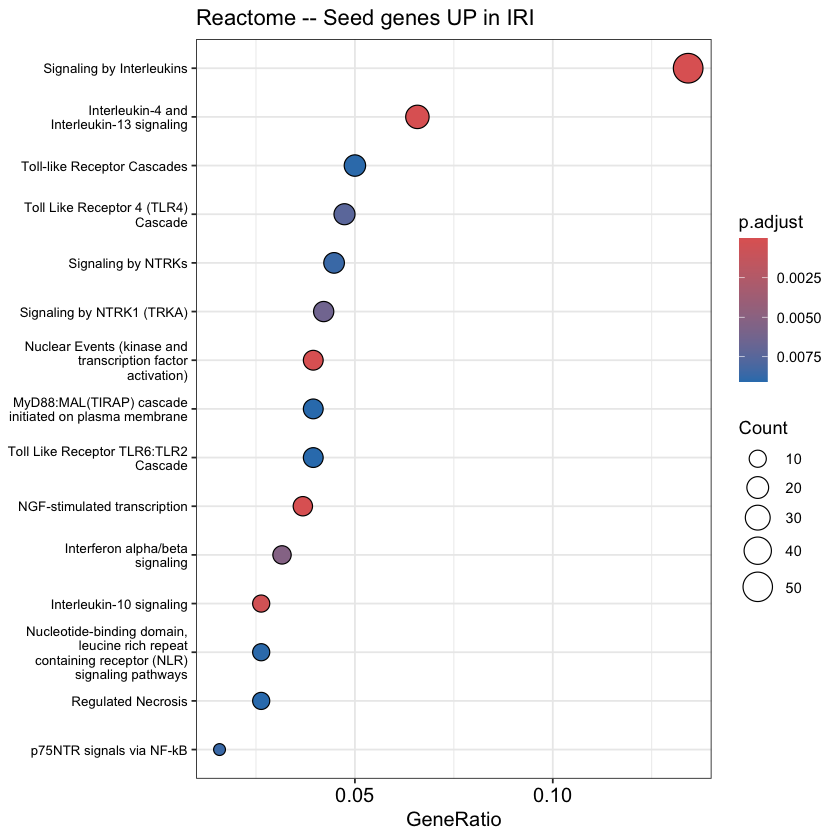

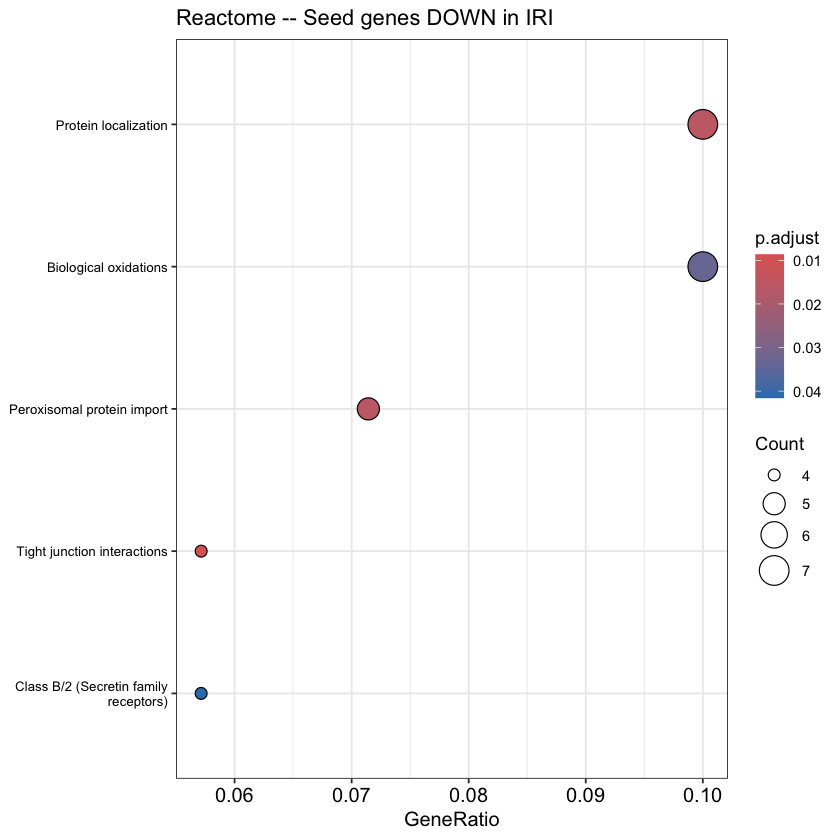

In [12]:
# ============================================================
# 3.6  ORA dotplots (publication-ready, 300 DPI JPG)
# ============================================================
if (nrow(as.data.frame(ora_up)) > 0) {
  p1 <- dotplot(ora_up, showCategory = 15, title = "Reactome -- Seed genes UP in IRI") +
    theme(axis.text.y = element_text(size = 8))
  print(p1)
  ggsave(file.path(OUT_DIR, "dotplot_ORA_up.jpg"), p1,
         width = 10, height = 7, dpi = 300, bg = "white")
}
if (nrow(as.data.frame(ora_down)) > 0) {
  p2 <- dotplot(ora_down, showCategory = 15, title = "Reactome -- Seed genes DOWN in IRI") +
    theme(axis.text.y = element_text(size = 8))
  print(p2)
  ggsave(file.path(OUT_DIR, "dotplot_ORA_down.jpg"), p2,
         width = 10, height = 7, dpi = 300, bg = "white")
}

## 4. Cat. B validation (GSE54888 -- DGF vs IGF)

In [13]:
# ============================================================
# 4.1  Pre-ranked GSEA of seed genes on Cat. B ranking
#      Tests both the full seed set and the HC subset
# ============================================================
de_b <- de_cat_b[["GSE54888"]] %>%
  dplyr::filter(!is.na(pvalue), pvalue > 0) %>%
  dplyr::mutate(rank_score = sign(log2FoldChange) * (-log10(pvalue))) %>%
  dplyr::distinct(gene, .keep_all = TRUE) %>%
  dplyr::arrange(desc(rank_score))

ranking_b <- setNames(de_b$rank_score, de_b$gene)

seed_sets <- list(
  IRI_seed_genes    = seed_genes$gene,
  IRI_seed_genes_HC = seed_genes_hc$gene
)

gsea_validation <- fgsea::fgsea(pathways = seed_sets, stats = ranking_b,
                                minSize = 5, nPermSimple = 100000)

cat("== GSEA validation on Cat. B (DGF vs IGF) ==\n")
print(gsea_validation[, c("pathway", "pval", "padj", "ES", "NES", "size")])

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."


== GSEA validation on Cat. B (DGF vs IGF) ==
             pathway         pval         padj        ES      NES  size
              <char>        <num>        <num>     <num>    <num> <int>
1:    IRI_seed_genes 9.413792e-11 9.413792e-11 0.3576941 1.731280   636
2: IRI_seed_genes_HC 2.630161e-18 5.260321e-18 0.5322337 2.385383   266


In [14]:
# ============================================================
# 4.2  Save validation results
# ============================================================
val_full <- gsea_validation[pathway == "IRI_seed_genes"]
val_hc   <- gsea_validation[pathway == "IRI_seed_genes_HC"]

validation_summary <- data.frame(
  test  = c("Full_GSEA_NES", "Full_GSEA_pval", "Full_N",
            "HC_GSEA_NES", "HC_GSEA_pval", "HC_N"),
  value = c(val_full$NES, val_full$pval, val_full$size,
            val_hc$NES, val_hc$pval, val_hc$size)
)
write.csv(validation_summary, file = file.path(OUT_DIR, "validation_catB_summary.csv"),
          row.names = FALSE)
cat("Validation results saved.\n")

Validation results saved.


## 5. Co-expression networks (MUUMI Module 2)

We infer separate networks for IRI and Control conditions on two platforms:  
- **GSE43974** (microarray, n=169 IRI + 37 Ctrl) -- robust network  
- **GSE126805** (RNA-seq, n=42 IRI + 41 Ctrl) -- robust network  

GSE142077 (n=5 per condition) is excluded from network inference due to insufficient sample size, but contributes to the statistical meta-analysis.

In [15]:
# ============================================================
# 5.1  Load expression matrices and sample labels
# ============================================================
load_expr <- function(path) {
  if (!file.exists(path)) { message(sprintf("Not found: %s", path)); return(NULL) }
  as.data.frame(read.csv(path, row.names = 1, check.names = FALSE))
}
load_labels <- function(path) {
  if (!file.exists(path)) return(NULL)
  read.csv(path, stringsAsFactors = FALSE)
}

expr_list   <- lapply(expr_files, load_expr)
labels_list <- lapply(label_files, load_labels)

# Datasets used for network inference (exclude GSE142077: too few samples)
net_datasets <- c("GSE43974", "GSE126805")
for (id in net_datasets) {
  if (is.null(expr_list[[id]])) cat(sprintf("WARNING: %s not available!\n", id))
  else cat(sprintf("%s: %d genes x %d samples\n", id, nrow(expr_list[[id]]), ncol(expr_list[[id]])))
}

GSE43974: 28794 genes x 206 samples
GSE126805: 18832 genes x 163 samples


In [16]:
# ============================================================
# 5.2  Subset to seed genes, split by IRI/Control
# ============================================================
prepare_expr_by_condition <- function(expr_df, labels_df, gene_subset) {
  common_genes <- intersect(rownames(expr_df), gene_subset)
  expr_sub <- expr_df[common_genes, , drop = FALSE]
  iri_samples  <- labels_df$sample[labels_df$condition == "IRI"]
  ctrl_samples <- labels_df$sample[labels_df$condition == "Control"]
  list(
    iri     = expr_sub[, intersect(colnames(expr_sub), iri_samples), drop = FALSE],
    control = expr_sub[, intersect(colnames(expr_sub), ctrl_samples), drop = FALSE],
    genes   = common_genes
  )
}

net_gene_set <- seed_genes$gene

prepared <- list()
for (id in net_datasets) {
  if (!is.null(expr_list[[id]]) && !is.null(labels_list[[id]])) {
    prepared[[id]] <- prepare_expr_by_condition(expr_list[[id]], labels_list[[id]], net_gene_set)
    cat(sprintf("%s: %d genes, %d IRI, %d Ctrl\n", id,
                length(prepared[[id]]$genes),
                ncol(prepared[[id]]$iri), ncol(prepared[[id]]$control)))
  }
}

GSE43974: 650 genes, 169 IRI, 37 Ctrl
GSE126805: 650 genes, 42 IRI, 41 Ctrl


In [17]:
# ============================================================
# 5.3  Network inference helper function
#      CLR + Pearson correlation -> edge ranking -> binary network
# ============================================================
infer_network <- function(expr_df, label, ncores = 2) {
  cat(sprintf("  Inferring network %s (%d genes x %d samples)...\n",
              label, nrow(expr_df), ncol(expr_df)))
  
  rank_mat <- get_ranked_consensus_matrix(
    gx_table = expr_df, iMethods = c("clr"),
    iEst = c("pearson"), iDisc = c("none"), ncores = ncores
  )
  parsed <- parse_edge_rank_matrix(
    edge_rank_matrix = rank_mat, edge_selection_strategy = "default",
    mat_weights = "rank"
  )
  graph <- get_iGraph(parsed$bin_mat)
  
  cat(sprintf("  -> %d nodes, %d edges\n", vcount(graph), ecount(graph)))
  list(graph = graph, edge_rank = parsed$edge_rank)
}

In [18]:
# ============================================================
# 5.4  Network inference -- GSE43974 (microarray)
# ============================================================
cat("=== GSE43974 (microarray) ===\n")
net_43974_iri  <- infer_network(prepared[["GSE43974"]]$iri,  "GSE43974_IRI")
net_43974_ctrl <- infer_network(prepared[["GSE43974"]]$control, "GSE43974_Ctrl")

saveRDS(net_43974_iri$graph,  file.path(OUT_DIR, "network_iri_GSE43974.rds"))
saveRDS(net_43974_ctrl$graph, file.path(OUT_DIR, "network_ctrl_GSE43974.rds"))

=== GSE43974 (microarray) ===
  Inferring network GSE43974_IRI (650 genes x 169 samples)...
[1] "Calculate correlation matrix for method : clr"
[1] "Total Cores: 8"
[1] "Total Workers: 2"
[1] "DoPar Name: doParallelSNOW"
[1] "Before For Each, Number of Combinations:1"
[1] "Only one matrix, not computing median!"
[1] "Return Matrix"
[1] "Get ranked edges for method : clr"
[1] "Perform Borda on list of list of ranked edges."
[1] "Get a consensus binary matrix by selecting the most significant ranked edges from median rank of Borda result."
[1] "Rank matrix computed, returning!"
[1] "Getting edge list ordered by rank..."
[1] "ordOption : FALSE"
[1] "numeric"
[1] "edge rank before:210925"
[1] "S100A8;S100A9" "HBA2;HBB"      "HBA1;HBA2"     "IFIT2;IFIT3"  
[5] "HBA1;HBB"      "HSD17B7;ZNF14"
[1] "input genes : 650"
[1] "Cutoff before break:4229"
[1] "Cutoff:4229"
[1] "edge rank after:4229"
[1] "Returning!"
[1] "name"           "betweenness"    "closeness"      "degree"        
[5] "eigenvec

In [19]:
# ============================================================
# 5.5  Network inference -- GSE126805 (RNA-seq)
# ============================================================
cat("=== GSE126805 (RNA-seq) ===\n")
net_126805_iri  <- infer_network(prepared[["GSE126805"]]$iri,  "GSE126805_IRI")
net_126805_ctrl <- infer_network(prepared[["GSE126805"]]$control, "GSE126805_Ctrl")

saveRDS(net_126805_iri$graph,  file.path(OUT_DIR, "network_iri_GSE126805.rds"))
saveRDS(net_126805_ctrl$graph, file.path(OUT_DIR, "network_ctrl_GSE126805.rds"))

=== GSE126805 (RNA-seq) ===
  Inferring network GSE126805_IRI (650 genes x 42 samples)...
[1] "Calculate correlation matrix for method : clr"
[1] "Total Cores: 8"
[1] "Total Workers: 2"
[1] "DoPar Name: doParallelSNOW"
[1] "Before For Each, Number of Combinations:1"
[1] "Only one matrix, not computing median!"
[1] "Return Matrix"
[1] "Get ranked edges for method : clr"
[1] "Perform Borda on list of list of ranked edges."
[1] "Get a consensus binary matrix by selecting the most significant ranked edges from median rank of Borda result."
[1] "Rank matrix computed, returning!"
[1] "Getting edge list ordered by rank..."
[1] "ordOption : FALSE"
[1] "numeric"
[1] "edge rank before:210925"
[1] "HBA1;HBA2"           "S100A8;S100A9"       "HBA1;HBB"           
[4] "HBA2;HBB"            "HIST1H2AE;HIST1H2BG" "CLIC5;FGF1"         
[1] "input genes : 650"
[1] "Cutoff before break:4646"
[1] "Cutoff:4646"
[1] "edge rank after:4646"
[1] "Returning!"
[1] "name"           "betweenness"    "closeness"  

In [20]:
# ============================================================
# 5.6  Community detection (walktrap, all 4 networks)
# ============================================================
modules_43974_iri   <- get_modules(net_43974_iri$graph,   method = "walktrap")
modules_43974_ctrl  <- get_modules(net_43974_ctrl$graph,  method = "walktrap")
modules_126805_iri  <- get_modules(net_126805_iri$graph,  method = "walktrap")
modules_126805_ctrl <- get_modules(net_126805_ctrl$graph, method = "walktrap")

cat(sprintf("GSE43974  IRI:  %d modules\n", length(unique(membership(modules_43974_iri)))))
cat(sprintf("GSE43974  Ctrl: %d modules\n", length(unique(membership(modules_43974_ctrl)))))
cat(sprintf("GSE126805 IRI:  %d modules\n", length(unique(membership(modules_126805_iri)))))
cat(sprintf("GSE126805 Ctrl: %d modules\n", length(unique(membership(modules_126805_ctrl)))))

GSE43974  IRI:  11 modules
GSE43974  Ctrl: 20 modules
GSE126805 IRI:  9 modules
GSE126805 Ctrl: 11 modules


In [21]:
# ============================================================
# 5.7  Functional annotation (Reactome) -- microarray networks
# ============================================================
cat("=== Pathway enrichment GSE43974 IRI ===\n")
get_reactome_from_modules(modules_43974_iri, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_micro_iri"), layout = "overall")

cat("\n=== Pathway enrichment GSE43974 Ctrl ===\n")
get_reactome_from_modules(modules_43974_ctrl, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_micro_ctrl"), layout = "overall")

=== Pathway enrichment GSE43974 IRI ===
The files will be exported in  ../output/fase2/pathway_micro_iri 


'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"0.54% of input gene IDs are fail to map..."


   SYMBOL ENTREZID
1  ABHD10    55347
2  ABHD11    83451
3 ADAMTS1     9510
4    AGR3   155465
5   ALAS1      211
6 ANKRD46   157567
                         ID
R-HSA-6785807 R-HSA-6785807
R-HSA-449147   R-HSA-449147
R-HSA-9031628 R-HSA-9031628
R-HSA-198725   R-HSA-198725
R-HSA-187037   R-HSA-187037
R-HSA-6783783 R-HSA-6783783
                                                              Description
R-HSA-6785807                  Interleukin-4 and Interleukin-13 signaling
R-HSA-449147                                    Signaling by Interleukins
R-HSA-9031628                                NGF-stimulated transcription
R-HSA-198725  Nuclear Events (kinase and transcription factor activation)
R-HSA-187037                                    Signaling by NTRK1 (TRKA)
R-HSA-6783783                                    Interleukin-10 signaling
              GeneRatio   BgRatio RichFactor FoldEnrichment    zScore
R-HSA-6785807    15/131 108/11146 0.13888889      11.817218 12.318723
R-HSA-449147 

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"0.84% of input gene IDs are fail to map..."


   SYMBOL ENTREZID
1  ABLIM3    22885
2 ADAMTS9    56999
3   ADH1B      125
4     AGT      183
5    AMZ2    51321
6 ANGPTL4    51129
 [1] ID             Description    GeneRatio      BgRatio        RichFactor    
 [6] FoldEnrichment zScore         pvalue         p.adjust       qvalue        
[11] geneID         Count         
<0 righe> (o 0-length row.names)


...

'select()' returned 1:1 mapping between keys and columns



  SYMBOL ENTREZID
1 ABLIM3    22885
2  ASB15   142685
3   CHP2    63928
4  CPNE6     9362
5   DPP6     1804
6  FRMD1    79981
 [1] ID             Description    GeneRatio      BgRatio        RichFactor    
 [6] FoldEnrichment zScore         pvalue         p.adjust       qvalue        
[11] geneID         Count         
<0 righe> (o 0-length row.names)


'select()' returned 1:1 mapping between keys and columns



   SYMBOL ENTREZID
1    AGR3   155465
2    BRD2     6046
3   CASP3      836
4 CCDC117   150275
5  CHMP1B    57132
6 COLEC11    78989
                         ID
R-HSA-191273   R-HSA-191273
R-HSA-2426168 R-HSA-2426168
R-HSA-1655829 R-HSA-1655829
                                                          Description GeneRatio
R-HSA-191273                                 Cholesterol biosynthesis      3/19
R-HSA-2426168          Activation of gene expression by SREBF (SREBP)      3/19
R-HSA-1655829 Regulation of cholesterol biosynthesis by SREBP (SREBF)      3/19
               BgRatio RichFactor FoldEnrichment    zScore       pvalue
R-HSA-191273  27/11146 0.11111111       65.18129 13.797018 1.197099e-05
R-HSA-2426168 42/11146 0.07142857       41.90226 10.973874 4.623032e-05
R-HSA-1655829 55/11146 0.05454545       31.99809  9.522668 1.041797e-04
                 p.adjust      qvalue            geneID Count
R-HSA-191273  0.001771706 0.001247503 HMGCR/HMGCS1/SQLE     3
R-HSA-2426168 0.0034210

[1] "Analysis completed!!!"

In [22]:
# ============================================================
# 5.8  Functional annotation -- RNA-seq networks
# ============================================================
cat("=== Pathway enrichment GSE126805 IRI ===\n")
get_reactome_from_modules(modules_126805_iri, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_rnaseq_iri"), layout = "overall")

cat("\n=== Pathway enrichment GSE126805 Ctrl ===\n")
get_reactome_from_modules(modules_126805_ctrl, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_rnaseq_ctrl"), layout = "overall")

=== Pathway enrichment GSE126805 IRI ===
The files will be exported in  ../output/fase2/pathway_rnaseq_iri 


'select()' returned 1:1 mapping between keys and columns



   SYMBOL ENTREZID
1  ABHD11    83451
2 ADAMTS1     9510
3   ALAS1      211
4  ARID5A    10865
5   ARL14    80117
6   ARL4D      379
                         ID                                Description
R-HSA-6785807 R-HSA-6785807 Interleukin-4 and Interleukin-13 signaling
R-HSA-6783783 R-HSA-6783783                   Interleukin-10 signaling
R-HSA-449147   R-HSA-449147                  Signaling by Interleukins
R-HSA-909733   R-HSA-909733            Interferon alpha/beta signaling
R-HSA-913531   R-HSA-913531                       Interferon Signaling
R-HSA-9031628 R-HSA-9031628               NGF-stimulated transcription
              GeneRatio   BgRatio RichFactor FoldEnrichment    zScore
R-HSA-6785807     10/76 108/11146 0.09259259      13.579435 10.884308
R-HSA-6783783      7/76  47/11146 0.14893617      21.842665 11.864058
R-HSA-449147      14/76 473/11146 0.02959831       4.340826  6.151969
R-HSA-909733       6/76  77/11146 0.07792208      11.427888  7.607826
R-HSA-913531       9

'select()' returned 1:1 mapping between keys and columns



    SYMBOL ENTREZID
1 ATP6V0E2   155066
2    CALCA      796
3     CBX7    23492
4 CDC42EP4    23580
5   CLDN11     5010
6   CLDN14    23562
                         ID                     Description GeneRatio   BgRatio
R-HSA-1500931 R-HSA-1500931         Cell-Cell communication      7/48 153/11146
R-HSA-420029   R-HSA-420029     Tight junction interactions      4/48  29/11146
R-HSA-421270   R-HSA-421270 Cell-cell junction organization      5/48  88/11146
R-HSA-446728   R-HSA-446728      Cell junction organization      5/48 115/11146
              RichFactor FoldEnrichment    zScore       pvalue    p.adjust
R-HSA-1500931 0.04575163       10.62391  7.882745 3.676763e-06 0.001013183
R-HSA-420029  0.13793103       32.02874 11.002910 6.643822e-06 0.001013183
R-HSA-421270  0.05681818       13.19366  7.552231 3.585364e-05 0.003645120
R-HSA-446728  0.04347826       10.09601  6.448087 1.287811e-04 0.009819558
                    qvalue                                        geneID Count
R-HSA-

...

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"30.77% of input gene IDs are fail to map..."


   SYMBOL ENTREZID
1   AHSA1    10598
2  CACYBP    27101
3 CCDC117   150275
4 CHORDC1    26973
5  DNAJA1     3301
6  DNAJA4    55466
                         ID
R-HSA-3371497 R-HSA-3371497
R-HSA-3371556 R-HSA-3371556
R-HSA-3371568 R-HSA-3371568
R-HSA-9613829 R-HSA-9613829
R-HSA-3371571 R-HSA-3371571
R-HSA-2173782 R-HSA-2173782
                                                                                      Description
R-HSA-3371497 HSP90 chaperone cycle for steroid hormone receptors (SHR) in the presence of ligand
R-HSA-3371556                                                    Cellular response to heat stress
R-HSA-3371568                                                                   Attenuation phase
R-HSA-9613829                                                        Chaperone Mediated Autophagy
R-HSA-3371571                                                      HSF1-dependent transactivation
R-HSA-2173782                                Binding and Uptake of Ligands by Scave

'select()' returned 1:1 mapping between keys and columns



  SYMBOL ENTREZID
1  ADRB2      154
2  ANXA1      301
3   CCR2   729230
4   CD69      969
5  CXCR4     7852
6 DUSP10    11221
                         ID                          Description GeneRatio
R-HSA-500792   R-HSA-500792                  GPCR ligand binding      6/17
R-HSA-373076   R-HSA-373076 Class A/1 (Rhodopsin-like receptors)      5/17
R-HSA-112409   R-HSA-112409   RAF-independent MAPK1/3 activation      2/17
R-HSA-418594   R-HSA-418594        G alpha (i) signalling events      4/17
R-HSA-5675221 R-HSA-5675221  Negative regulation of MAPK pathway      2/17
R-HSA-6783783 R-HSA-6783783             Interleukin-10 signaling      2/17
                BgRatio RichFactor FoldEnrichment    zScore       pvalue
R-HSA-500792  468/11146 0.01282051       8.405732  6.397088 4.422442e-05
R-HSA-373076  334/11146 0.01497006       9.815076  6.392676 1.078045e-04
R-HSA-112409   23/11146 0.08695652      57.012788 10.509367 5.436337e-04
R-HSA-418594  318/11146 0.01257862       8.247133  5.1243

[1] "Analysis completed!!!"

Bubble plot GSE43974 IRI:


'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"0.54% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"0.84% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"1.47% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"3.74% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"57.14% of input gene IDs are fail to map.


Bubble plot GSE126805 IRI:


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"1.26% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"19.23% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"2.5% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


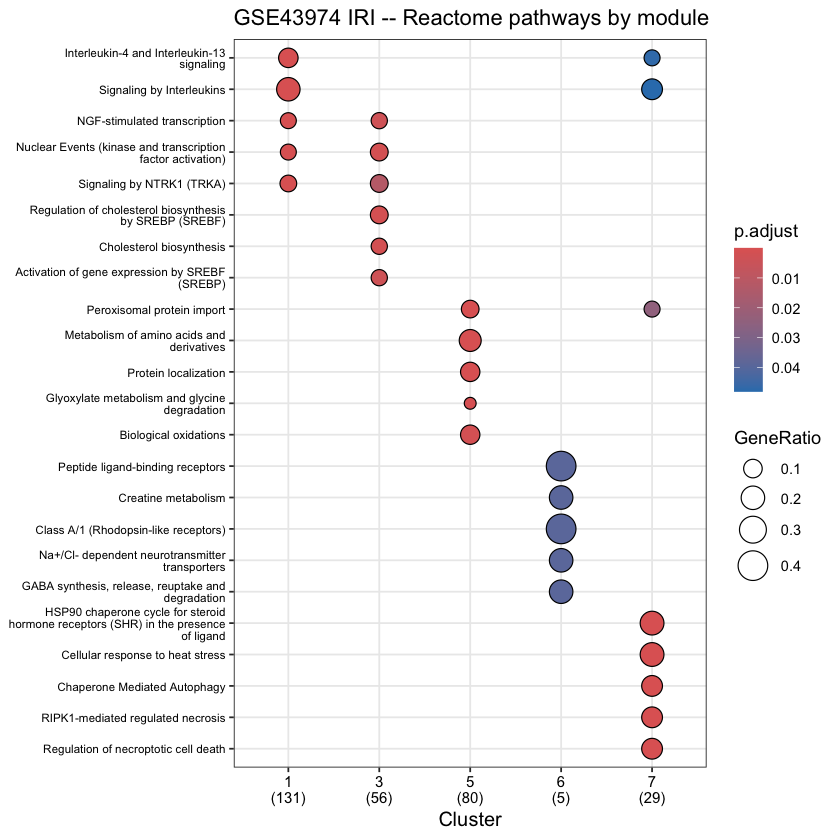

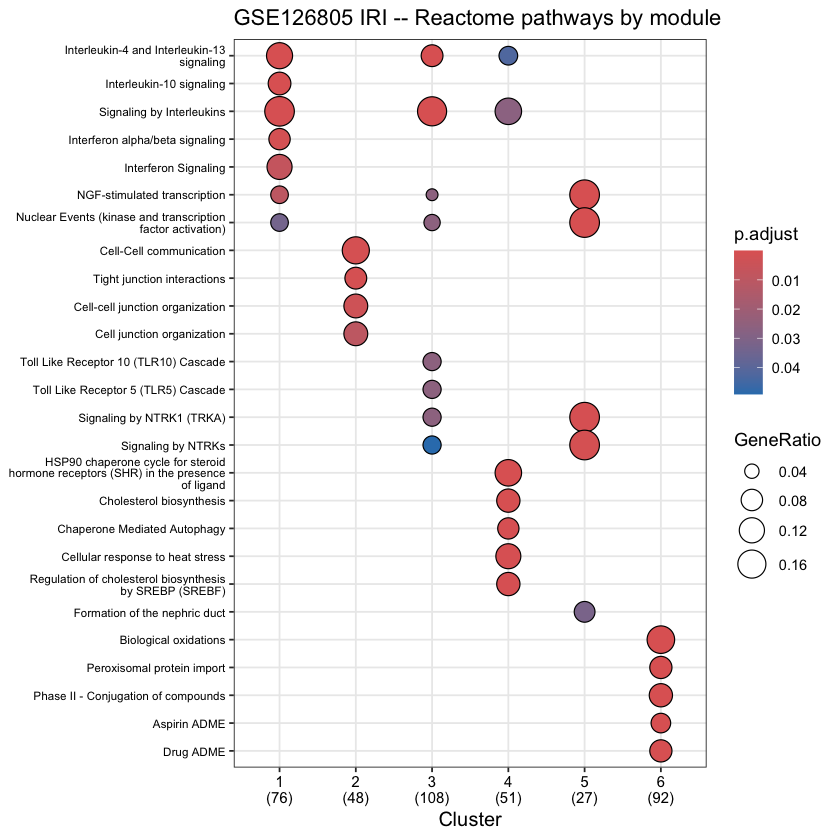

In [23]:
# ============================================================
# 5.9  Bubble plots (publication-ready, saved as JPG 300 DPI)
# ============================================================

# Helper: build a clean dotplot from compareCluster result
make_bubble <- function(modules, geneID = "SYMBOL", title = "", width = 40) {
  # Reproduce what get_bubbleplot_from_pathways does internally
  lst <- list()
  if (class(modules) == "communities") {
    members <- igraph::membership(modules)
    for (mod in seq_along(unique(members))) {
      x <- names(members[members == mod])
      if (length(x) > 10) {
        convgenes <- clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", OrgDb = org.Hs.eg.db)
        lst[[as.character(mod)]] <- convgenes$ENTREZID
      }
    }
  }
  lst[sapply(lst, is.null)] <- NULL
  res <- clusterProfiler::compareCluster(lst, fun = "enrichPathway")
  
  # Build ggplot dotplot with proper label wrapping
  p <- clusterProfiler::dotplot(res, showCategory = 5) +
    scale_y_discrete(labels = function(x) stringr::str_wrap(x, width = width)) +
    theme(
      axis.text.y = element_text(size = 7, lineheight = 0.85),
      axis.text.x = element_text(size = 9)
    ) +
    ggtitle(title)
  p
}

cat("Bubble plot GSE43974 IRI:\n")
bp_43974 <- make_bubble(modules_43974_iri, title = "GSE43974 IRI -- Reactome pathways by module")
print(bp_43974)
ggsave(file.path(OUT_DIR, "bubbleplot_micro_iri.jpg"), bp_43974,
       width = 12, height = 9, dpi = 300, bg = "white")

cat("\nBubble plot GSE126805 IRI:\n")
bp_126805 <- make_bubble(modules_126805_iri, title = "GSE126805 IRI -- Reactome pathways by module")
print(bp_126805)
ggsave(file.path(OUT_DIR, "bubbleplot_rnaseq_iri.jpg"), bp_126805,
       width = 12, height = 9, dpi = 300, bg = "white")

## 6. Cross-platform late integration (MUUMI Module 3)

We aggregate co-expression modules from microarray (GSE43974) and RNA-seq (GSE126805) using `aggregate_communities()` from MUUMI, which employs Non-negative Matrix Factorization (NMF) to identify shared meta-modules across platforms (Inkala et al., 2026, Module 3).

In [24]:
# ============================================================
# 6.1  Late integration -- IRI networks
# ============================================================

# Prepare community labels as named lists (required format)
micro_cl_iri  <- setNames(as.list(membership(modules_43974_iri)),  modules_43974_iri$names)
rnaseq_cl_iri <- setNames(as.list(membership(modules_126805_iri)), modules_126805_iri$names)

community_labels_iri <- list("micro" = micro_cl_iri, "rnaseq" = rnaseq_cl_iri)

# Number of aggregated communities = rounded average
n_micro_iri  <- max(membership(modules_43974_iri))
n_rnaseq_iri <- max(membership(modules_126805_iri))
n_agg_iri    <- round((n_micro_iri + n_rnaseq_iri) / 2)

cat(sprintf("Micro IRI: %d, RNA-seq IRI: %d -> aggregated: %d\n",
            n_micro_iri, n_rnaseq_iri, n_agg_iri))

agg_iri <- aggregate_communities(
  community_labels_iri,
  n_aggregate_communities = n_agg_iri,
  max_iter = 50000
)

most_probable_iri <- get_most_probable_community(agg_iri)
cat(sprintf("Integrated IRI genes: %d in %d aggregated communities\n",
            length(most_probable_iri), length(unique(most_probable_iri))))

Micro IRI: 11, RNA-seq IRI: 9 -> aggregated: 10
Integrated IRI genes: 650 in 10 aggregated communities


In [25]:
# ============================================================
# 6.2  Late integration -- Control networks
# ============================================================
micro_cl_ctrl  <- setNames(as.list(membership(modules_43974_ctrl)),  modules_43974_ctrl$names)
rnaseq_cl_ctrl <- setNames(as.list(membership(modules_126805_ctrl)), modules_126805_ctrl$names)

community_labels_ctrl <- list("micro" = micro_cl_ctrl, "rnaseq" = rnaseq_cl_ctrl)

n_micro_ctrl  <- max(membership(modules_43974_ctrl))
n_rnaseq_ctrl <- max(membership(modules_126805_ctrl))
n_agg_ctrl    <- round((n_micro_ctrl + n_rnaseq_ctrl) / 2)

cat(sprintf("Micro Ctrl: %d, RNA-seq Ctrl: %d -> aggregated: %d\n",
            n_micro_ctrl, n_rnaseq_ctrl, n_agg_ctrl))

agg_ctrl <- aggregate_communities(
  community_labels_ctrl,
  n_aggregate_communities = n_agg_ctrl,
  max_iter = 50000
)

most_probable_ctrl <- get_most_probable_community(agg_ctrl)
cat(sprintf("Integrated Ctrl genes: %d in %d aggregated communities\n",
            length(most_probable_ctrl), length(unique(most_probable_ctrl))))

Micro Ctrl: 20, RNA-seq Ctrl: 11 -> aggregated: 16
Integrated Ctrl genes: 650 in 16 aggregated communities


In [26]:
# ============================================================
# 6.3  Platform contributions to each aggregated community
# ============================================================
cat("=== Platform contributions -- IRI communities ===\n")
print(round(agg_iri$view_contributions, 3))

cat("\n=== Platform contributions -- Ctrl communities ===\n")
print(round(agg_ctrl$view_contributions, 3))

=== Platform contributions -- IRI communities ===
        [,1]  [,2]  [,3]  [,4]  [,5]  [,6]  [,7]  [,8]  [,9] [,10]
micro  0.624 0.439 0.534 0.579 0.558 0.548 0.543 0.694 0.509 0.545
rnaseq 0.376 0.561 0.466 0.421 0.442 0.452 0.457 0.306 0.491 0.455

=== Platform contributions -- Ctrl communities ===
        [,1]  [,2] [,3]  [,4]  [,5]  [,6]  [,7]  [,8]  [,9] [,10] [,11] [,12]
micro  0.553 0.627 0.63 0.521 0.661 0.604 0.507 0.576 0.497 0.522 0.634 0.675
rnaseq 0.447 0.373 0.37 0.479 0.339 0.396 0.493 0.424 0.503 0.478 0.366 0.325
       [,13] [,14] [,15] [,16]
micro   0.66  0.58 0.569  0.53
rnaseq  0.34  0.42 0.431  0.47


In [27]:
# ============================================================
# 6.4  Functional annotation of integrated modules
# ============================================================
cat("=== Pathway enrichment -- integrated IRI communities ===\n")
get_reactome_from_modules(most_probable_iri, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_integrated_iri"), layout = "overall")

cat("\n=== Pathway enrichment -- integrated Ctrl communities ===\n")
get_reactome_from_modules(most_probable_ctrl, geneID = "SYMBOL", pval_cutoff = 0.05,
                          outPath = file.path(OUT_DIR, "pathway_integrated_ctrl"), layout = "overall")

=== Pathway enrichment -- integrated IRI communities ===
The files will be exported in  ../output/fase2/pathway_integrated_iri 


'select()' returned 1:1 mapping between keys and columns



   SYMBOL ENTREZID
1  ABHD11    83451
2 ADAMTS1     9510
3   ALAS1      211
4   ARL14    80117
5   ARL5B   221079
6   BATF3    55509
                         ID
R-HSA-6785807 R-HSA-6785807
R-HSA-449147   R-HSA-449147
R-HSA-6783783 R-HSA-6783783
R-HSA-9031628 R-HSA-9031628
R-HSA-6783589 R-HSA-6783589
R-HSA-198725   R-HSA-198725
                                                              Description
R-HSA-6785807                  Interleukin-4 and Interleukin-13 signaling
R-HSA-449147                                    Signaling by Interleukins
R-HSA-6783783                                    Interleukin-10 signaling
R-HSA-9031628                                NGF-stimulated transcription
R-HSA-6783589                              Interleukin-6 family signaling
R-HSA-198725  Nuclear Events (kinase and transcription factor activation)
              GeneRatio   BgRatio RichFactor FoldEnrichment    zScore
R-HSA-6785807      9/53 108/11146 0.08333333      17.525157 11.927948
R-HSA-449147 

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"3.33% of input gene IDs are fail to map..."


   SYMBOL ENTREZID
1 ABCC6P1   653190
3    AHCY      191
4    ALAD      210
5     ALB      213
6 ALDH3A2      224
7 ALDH5A1     7915
                         ID                               Description GeneRatio
R-HSA-9033241 R-HSA-9033241                Peroxisomal protein import      7/69
R-HSA-9609507 R-HSA-9609507                      Protein localization      8/69
R-HSA-211859   R-HSA-211859                     Biological oxidations      9/69
R-HSA-71291     R-HSA-71291 Metabolism of amino acids and derivatives     11/69
R-HSA-8963899 R-HSA-8963899             Plasma lipoprotein remodeling      4/69
R-HSA-9748784 R-HSA-9748784                                 Drug ADME      6/69
                BgRatio RichFactor FoldEnrichment    zScore       pvalue
R-HSA-9033241  63/11146 0.11111111      17.948470 10.646960 1.072988e-07
R-HSA-9609507 164/11146 0.04878049       7.879816  7.005055 7.224733e-06
R-HSA-211859  222/11146 0.04054054       6.548766  6.590761 8.424234e-06
R-HSA-71291   3

...

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"3.85% of input gene IDs are fail to map..."


   SYMBOL ENTREZID
1 ABCC6P1   653190
2  ABHD11    83451
3 ALDH5A1     7915
4 ANKRD46   157567
5     CPM     1368
6    CRY2     1408
                         ID
R-HSA-1237044 R-HSA-1237044
R-HSA-1480926 R-HSA-1480926
R-HSA-2168880 R-HSA-2168880
R-HSA-2173782 R-HSA-2173782
R-HSA-9707616 R-HSA-9707616
R-HSA-9707564 R-HSA-9707564
                                                         Description GeneRatio
R-HSA-1237044 Erythrocytes take up carbon dioxide and release oxygen      3/16
R-HSA-1480926                        O2/CO2 exchange in erythrocytes      3/16
R-HSA-2168880                         Scavenging of heme from plasma      3/16
R-HSA-2173782   Binding and Uptake of Ligands by Scavenger Receptors      3/16
R-HSA-9707616                                         Heme signaling      3/16
R-HSA-9707564                                Cytoprotection by HMOX1      3/16
               BgRatio RichFactor FoldEnrichment    zScore       pvalue
R-HSA-1237044 13/11146 0.23076923      160.759

'select()' returned 1:1 mapping between keys and columns



  SYMBOL ENTREZID
1  ADRB2      154
2  ANXA1      301
3   CCR2   729230
4   CD69      969
5  CXCR4     7852
6 DUSP10    11221
                         ID                          Description GeneRatio
R-HSA-500792   R-HSA-500792                  GPCR ligand binding      6/17
R-HSA-373076   R-HSA-373076 Class A/1 (Rhodopsin-like receptors)      5/17
R-HSA-112409   R-HSA-112409   RAF-independent MAPK1/3 activation      2/17
R-HSA-418594   R-HSA-418594        G alpha (i) signalling events      4/17
R-HSA-5675221 R-HSA-5675221  Negative regulation of MAPK pathway      2/17
R-HSA-6783783 R-HSA-6783783             Interleukin-10 signaling      2/17
                BgRatio RichFactor FoldEnrichment    zScore       pvalue
R-HSA-500792  468/11146 0.01282051       8.405732  6.397088 4.422442e-05
R-HSA-373076  334/11146 0.01497006       9.815076  6.392676 1.078045e-04
R-HSA-112409   23/11146 0.08695652      57.012788 10.509367 5.436337e-04
R-HSA-418594  318/11146 0.01257862       8.247133  5.1243

[1] "Analysis completed!!!"

Bubble plot -- integrated IRI communities:


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"3.33% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"1.32% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"18.52% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in cluster


Bubble plot -- integrated Ctrl communities:


'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"1.71% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"5.77% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"1.52% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", :
"3.23% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' r

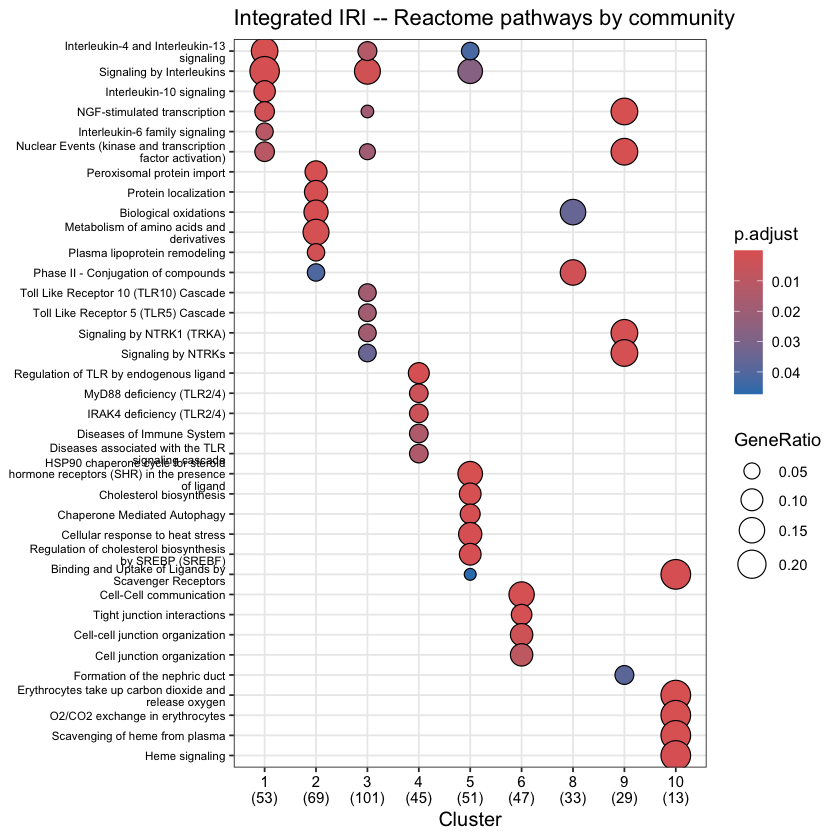

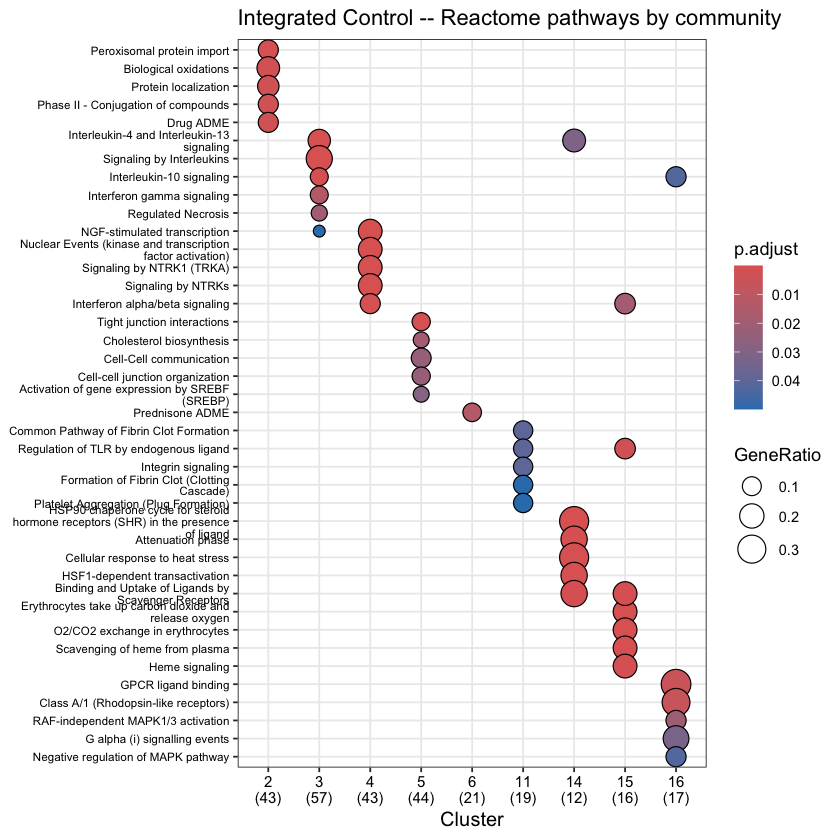

In [28]:
# ============================================================
# 6.5  Bubble plots of integrated modules
# ============================================================

make_bubble_int <- function(modules_int, geneID = "SYMBOL", title = "", width = 40) {
  members <- modules_int
  lst <- list()
  for (mod in sort(unique(members))) {
    x <- names(members[members == mod])
    if (length(x) > 10) {
      convgenes <- clusterProfiler::bitr(x, fromType = geneID, toType = "ENTREZID", OrgDb = org.Hs.eg.db)
      lst[[as.character(mod)]] <- convgenes$ENTREZID
    }
  }
  lst[sapply(lst, is.null)] <- NULL
  res <- clusterProfiler::compareCluster(lst, fun = "enrichPathway")
  
  p <- clusterProfiler::dotplot(res, showCategory = 5) +
    scale_y_discrete(labels = function(x) stringr::str_wrap(x, width = width)) +
    theme(
      axis.text.y = element_text(size = 7, lineheight = 0.85),
      axis.text.x = element_text(size = 9)
    ) +
    ggtitle(title)
  p
}

cat("Bubble plot -- integrated IRI communities:\n")
bp_int_iri <- make_bubble_int(most_probable_iri, title = "Integrated IRI -- Reactome pathways by community")
print(bp_int_iri)
ggsave(file.path(OUT_DIR, "bubbleplot_integrated_iri.jpg"), bp_int_iri,
       width = 12, height = 9, dpi = 300, bg = "white")

cat("\nBubble plot -- integrated Ctrl communities:\n")
bp_int_ctrl <- make_bubble_int(most_probable_ctrl, title = "Integrated Control -- Reactome pathways by community")
print(bp_int_ctrl)
ggsave(file.path(OUT_DIR, "bubbleplot_integrated_ctrl.jpg"), bp_int_ctrl,
       width = 12, height = 9, dpi = 300, bg = "white")

## 7. ESEA -- Edge Set Enrichment Analysis (MUUMI)

ESEA evaluates functional enrichment at the **edge** level (gene-gene interactions), not individual genes. This is a unique contribution of MUUMI: it identifies pathways whose genes are highly interconnected in the network, revealing functional coordination (Inkala et al., 2026, Module 4).

In [29]:
# ============================================================
# 7.1  Build pathway edge map from KEGG
# ============================================================
if (!requireNamespace("msigdbr", quietly = TRUE)) install.packages("msigdbr")
library(msigdbr)

# msigdbr v10+: parameter names may differ
kegg <- tryCatch(
  msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:KEGG"),
  error = function(e) {
    message("Trying updated parameter names...")
    msigdbr(species = "Homo sapiens", collection = "C2", subcollection = "CP:KEGG_MEDICUS")
  }
)
kegg_pathways <- split(kegg$gene_symbol, kegg$gs_name)
cat(sprintf("KEGG pathways loaded: %d\n", length(kegg_pathways)))

# Generate all gene-pair edges for each pathway
build_pathway_edge_map <- function(pw_list, network_genes, min_size = 3, max_size = 200) {
  edge_map <- list()
  for (pw_name in names(pw_list)) {
    genes <- intersect(pw_list[[pw_name]], network_genes)
    if (length(genes) >= min_size && length(genes) <= max_size) {
      pairs <- combn(sort(genes), 2)
      edges <- paste(pairs[1, ], pairs[2, ], sep = "|")
      edge_map[[pw_name]] <- edges
    }
  }
  edge_map
}

net_genes_iri <- V(net_43974_iri$graph)$name
pathway_edge_map <- build_pathway_edge_map(kegg_pathways, net_genes_iri)
cat(sprintf("Pathway edge map: %d pathways with valid edge sets\n", length(pathway_edge_map)))

Trying updated parameter names...



KEGG pathways loaded: 658
Pathway edge map: 47 pathways with valid edge sets


In [30]:
# ============================================================
# 7.2  Prepare edge score vector from IRI network
#      Score = inverse rank (top-ranked edges get highest score)
# ============================================================
edge_rank_iri <- net_43974_iri$edge_rank
edge_rank_iri <- gsub(";", "|", edge_rank_iri, fixed = TRUE)

esea_scores_iri <- rev(seq_along(edge_rank_iri))
names(esea_scores_iri) <- edge_rank_iri

cat(sprintf("Edge score vector: %d edges\n", length(esea_scores_iri)))
cat(sprintf("Top 5 edges: %s\n", paste(head(names(esea_scores_iri)), collapse = ", ")))

Edge score vector: 4229 edges
Top 5 edges: S100A8|S100A9, HBA2|HBB, HBA1|HBA2, IFIT2|IFIT3, HBA1|HBB, HSD17B7|ZNF14


In [31]:
# ============================================================
# 7.3  ESEA -- IRI network (GSE43974)
# ============================================================
esea_iri <- compute_esea(
  EdgeCorScore     = esea_scores_iri,
  pathway_edge_map = pathway_edge_map,
  weighted.score.type = 1,
  nperm            = 1000,
  FDR.threshold    = 0.05,
  topgs            = 5
)

cat("=== ESEA results -- IRI network (top of rank) ===\n")
esea_iri_pos <- esea_iri$SUMMARY.RESULTS$SUMMARY.RESULTS.High_portion_of_the_rank
if (nrow(esea_iri_pos) > 0) {
  print(head(esea_iri_pos[, c("GS", "SIZE", "ES", "NES", "NOM_pval", "FDR_qval")], 10))
} else {
  cat("No significantly enriched edge sets.\n")
}

Warning message:
"le stringhe non rappresentabili nella codifica nativa saranno tradotte in UTF-8"
Running ESEA Analysis (list-based, node1|node2)<U+2026>



=== ESEA results -- IRI network (top of rank) ===
                                                                                   GS
7                                           KEGG_MEDICUS_REFERENCE_MEVALONATE_PATHWAY
4             KEGG_MEDICUS_PATHOGEN_SARS_COV_2_S_TO_ANGII_AT1R_NOX2_SIGNALING_PATHWAY
1                        KEGG_MEDICUS_ENV_FACTOR_NNK_NNN_TO_RAS_ERK_SIGNALING_PATHWAY
5                               KEGG_MEDICUS_REFERENCE_IL1_IL1R_JNK_SIGNALING_PATHWAY
9                                KEGG_MEDICUS_REFERENCE_TLR2_4_MAPK_SIGNALING_PATHWAY
11 KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_PSEN1_TO_PERK_ATF4_SIGNALING_PATHWAY
12  KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_SNCA_TO_PERK_ATF4_SIGNALING_PATHWAY
13  KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_SOD1_TO_PERK_ATF4_SIGNALING_PATHWAY
14     KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PERK_ATF4_SIGNALING_PATHWAY
3                      KEGG_MEDICUS_PATHOGEN_HTLV_1_TAX_TO_SRF_MEDIATED_TRANSCRIPTION
   S

In [32]:
# ============================================================
# 7.4  ESEA -- Control network (GSE43974)
# ============================================================
edge_rank_ctrl <- net_43974_ctrl$edge_rank
edge_rank_ctrl <- gsub(";", "|", edge_rank_ctrl, fixed = TRUE)
esea_scores_ctrl <- rev(seq_along(edge_rank_ctrl))
names(esea_scores_ctrl) <- edge_rank_ctrl

# Rebuild edge map for Control network genes
net_genes_ctrl <- V(net_43974_ctrl$graph)$name
pathway_edge_map_ctrl <- build_pathway_edge_map(kegg_pathways, net_genes_ctrl)

esea_ctrl <- compute_esea(
  EdgeCorScore     = esea_scores_ctrl,
  pathway_edge_map = pathway_edge_map_ctrl,
  weighted.score.type = 1,
  nperm            = 1000,
  FDR.threshold    = 0.05,
  topgs            = 5
)

cat("=== ESEA results -- Control network (top of rank) ===\n")
esea_ctrl_pos <- esea_ctrl$SUMMARY.RESULTS$SUMMARY.RESULTS.High_portion_of_the_rank
if (nrow(esea_ctrl_pos) > 0) {
  print(head(esea_ctrl_pos[, c("GS", "SIZE", "ES", "NES", "NOM_pval", "FDR_qval")], 10))
} else {
  cat("No significantly enriched edge sets.\n")
}

Running ESEA Analysis (list-based, node1|node2)<U+2026>



=== ESEA results -- Control network (top of rank) ===
                                                                  GS SIZE
2     KEGG_MEDICUS_PATHOGEN_HTLV_1_TAX_TO_SRF_MEDIATED_TRANSCRIPTION    5
7                          KEGG_MEDICUS_REFERENCE_MEVALONATE_PATHWAY    1
1       KEGG_MEDICUS_ENV_FACTOR_NNK_NNN_TO_RAS_ERK_SIGNALING_PATHWAY    1
4              KEGG_MEDICUS_REFERENCE_IL1_IL1R_JNK_SIGNALING_PATHWAY    1
10              KEGG_MEDICUS_REFERENCE_TLR2_4_MAPK_SIGNALING_PATHWAY    1
6    KEGG_MEDICUS_REFERENCE_IL6_FAMILY_TO_JAK_STAT_SIGNALING_PATHWAY    1
11                KEGG_MEDICUS_REFERENCE_WNT5A_ROR_SIGNALING_PATHWAY    1
12                      KEGG_MEDICUS_REFERENCE_WNT_SIGNALING_PATHWAY    1
13 KEGG_MEDICUS_VARIANT_LRP6_OVEREXPRESSION_TO_WNT_SIGNALING_PATHWAY    1
        ES    NES NOM_pval  FDR_qval
2  0.74234 1.5770    0.013 0.0624000
7  0.98963 1.3113    0.008 0.0624000
1  0.97797 1.2958    0.024 0.0624000
4  0.97797 1.2958    0.024 0.0624000
10 0.97797 1.2958    

In [33]:
# ============================================================
# 7.5  Save ESEA results
# ============================================================
if (nrow(esea_iri_pos) > 0) {
  write.csv(esea_iri_pos, file = file.path(OUT_DIR, "esea_iri_results.csv"), row.names = FALSE)
}
if (nrow(esea_ctrl_pos) > 0) {
  write.csv(esea_ctrl_pos, file = file.path(OUT_DIR, "esea_ctrl_results.csv"), row.names = FALSE)
}
cat("ESEA results saved.\n")

ESEA results saved.


## 8. PPI network analysis (STRINGdb)

We construct a protein-protein interaction (PPI) network from the seed genes using the STRING database (score > 700, high-confidence interactions). Community detection, centrality-based hub gene ranking, and functional annotation of PPI modules complement the data-driven co-expression analysis from Section 5. Convergence between PPI hubs and co-expression hubs provides independent validation of candidate targets.

In [34]:
# ============================================================
# 8.1  Load STRINGdb and map seed genes
# ============================================================
if (!requireNamespace("STRINGdb", quietly = TRUE)) {
  BiocManager::install("STRINGdb")
}
library(STRINGdb)

# Initialize STRINGdb: human (species 9606), high-confidence (score >= 700)
string_db <- STRINGdb$new(
  version    = "12.0",
  species    = 9606,
  score_threshold = 700,
  network_type    = "full"
)

# Prepare seed gene data frame for mapping
seed_df <- data.frame(gene = seed_genes$gene, stringsAsFactors = FALSE)

# Map gene symbols to STRING IDs
seed_mapped <- string_db$map(seed_df, "gene", removeUnmappedRows = TRUE)

# Remove duplicate mappings: keep first match per gene
seed_mapped <- seed_mapped[!duplicated(seed_mapped$gene), ]

cat(sprintf("Seed genes mapped to STRING: %d / %d (%.1f%%)\n",
            nrow(seed_mapped), nrow(seed_genes),
            100 * nrow(seed_mapped) / nrow(seed_genes)))

In [35]:
# ============================================================
# 8.2  Retrieve PPI network and build igraph object
# ============================================================

# Get interactions between mapped seed genes
string_ids <- seed_mapped$STRING_id
ppi_edges <- string_db$get_interactions(string_ids)

cat(sprintf("STRING interactions retrieved: %d edges\n", nrow(ppi_edges)))

# Build igraph from STRING edges
# Map STRING IDs back to gene symbols for readability
id_to_gene <- setNames(seed_mapped$gene, seed_mapped$STRING_id)

ppi_edges$from_gene <- id_to_gene[ppi_edges$from]
ppi_edges$to_gene   <- id_to_gene[ppi_edges$to]

# Remove edges where mapping failed
ppi_edges <- ppi_edges[!is.na(ppi_edges$from_gene) & !is.na(ppi_edges$to_gene), ]

# Create igraph object
ppi_graph <- igraph::graph_from_data_frame(
  ppi_edges[, c("from_gene", "to_gene")],
  directed = FALSE
)
ppi_graph <- igraph::simplify(ppi_graph)  # remove self-loops and duplicates

cat(sprintf("PPI network: %d nodes, %d edges\n",
            igraph::vcount(ppi_graph), igraph::ecount(ppi_graph)))

# Keep only the largest connected component for analysis
components <- igraph::components(ppi_graph)
largest_cc <- which.max(components$csize)
ppi_graph_cc <- igraph::induced_subgraph(
  ppi_graph,
  which(components$membership == largest_cc)
)

cat(sprintf("Largest connected component: %d nodes, %d edges\n",
            igraph::vcount(ppi_graph_cc), igraph::ecount(ppi_graph_cc)))

STRING interactions retrieved: 2294 edges
PPI network: 388 nodes, 1147 edges
Largest connected component: 345 nodes, 1112 edges


In [36]:
# ============================================================
# 8.3  Centrality analysis and hub gene identification
# ============================================================

# Compute centrality metrics
centrality_df <- data.frame(
  gene         = igraph::V(ppi_graph_cc)$name,
  degree       = igraph::degree(ppi_graph_cc),
  betweenness  = igraph::betweenness(ppi_graph_cc, normalized = TRUE),
  closeness    = igraph::closeness(ppi_graph_cc, normalized = TRUE),
  eigenvector  = igraph::eigen_centrality(ppi_graph_cc)$vector,
  pagerank     = igraph::page_rank(ppi_graph_cc)$vector,
  stringsAsFactors = FALSE
)

# Composite hub score: average rank across all centrality measures
centrality_df$rank_degree      <- rank(-centrality_df$degree)
centrality_df$rank_betweenness <- rank(-centrality_df$betweenness)
centrality_df$rank_closeness   <- rank(-centrality_df$closeness)
centrality_df$rank_eigenvector <- rank(-centrality_df$eigenvector)
centrality_df$rank_pagerank    <- rank(-centrality_df$pagerank)

centrality_df$hub_score <- rowMeans(centrality_df[, grep("^rank_", colnames(centrality_df))])
centrality_df <- centrality_df[order(centrality_df$hub_score), ]

# Add HC flag
centrality_df$high_confidence <- centrality_df$gene %in% seed_genes_hc$gene

# Top 30 PPI hub genes
ppi_hubs <- head(centrality_df, 30)
cat("Top 30 PPI hub genes (composite centrality score):\n")
print(ppi_hubs[, c("gene", "degree", "betweenness", "eigenvector", "pagerank", "high_confidence")])

# Save full centrality table
write.csv(centrality_df, file = file.path(OUT_DIR, "ppi_centrality_analysis.csv"),
          row.names = FALSE)
cat(sprintf("\nPPI hub genes (HC): %d / %d in top 30\n",
            sum(ppi_hubs$high_confidence), nrow(ppi_hubs)))

Top 30 PPI hub genes (composite centrality score):
             gene degree betweenness eigenvector    pagerank high_confidence
IL6           IL6     57 0.225896331   1.0000000 0.018749488            TRUE
FOS           FOS     47 0.100854485   0.7298647 0.015508382           FALSE
JUN           JUN     47 0.087674697   0.8184602 0.014715300            TRUE
IL1B         IL1B     43 0.068016854   0.8912483 0.013174434           FALSE
MYC           MYC     29 0.093123832   0.5363713 0.011136189            TRUE
HSP90AA1 HSP90AA1     38 0.093100207   0.5245172 0.012458566            TRUE
NFKBIA     NFKBIA     29 0.058121491   0.5767756 0.009402603           FALSE
ALB           ALB     26 0.196320452   0.3885251 0.010477630           FALSE
HSP90AB1 HSP90AB1     33 0.074562312   0.4762005 0.010962417            TRUE
CASP3       CASP3     27 0.056394462   0.5513471 0.008835495           FALSE
HSPA5       HSPA5     28 0.062999064   0.3784311 0.009169205            TRUE
CCL2         CCL2     30 

In [37]:
# ============================================================
# 8.4  Community detection on PPI network (Louvain)
# ============================================================
set.seed(0)
ppi_communities <- igraph::cluster_louvain(ppi_graph_cc)

cat(sprintf("PPI communities (Louvain): %d modules\n",
            length(unique(igraph::membership(ppi_communities)))))
cat(sprintf("Modularity: %.3f\n", igraph::modularity(ppi_communities)))

# Module sizes
mod_sizes <- table(igraph::membership(ppi_communities))
cat("\nModule sizes:\n")
print(mod_sizes)

PPI communities (Louvain): 16 modules
Modularity: 0.637

Module sizes:

 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 
30 66 54 52 17 23 19 13 21  5  7  3 14  4  7 10 


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(mod_genes, fromType = "SYMBOL", toType = "ENTREZID", :
"1.92% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in clusterProfiler::bitr(mod_genes, fromType = "SYMBOL", toType = "ENTREZID", :
"43.48% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1

PPI modules with >= 5 mapped genes: 14


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


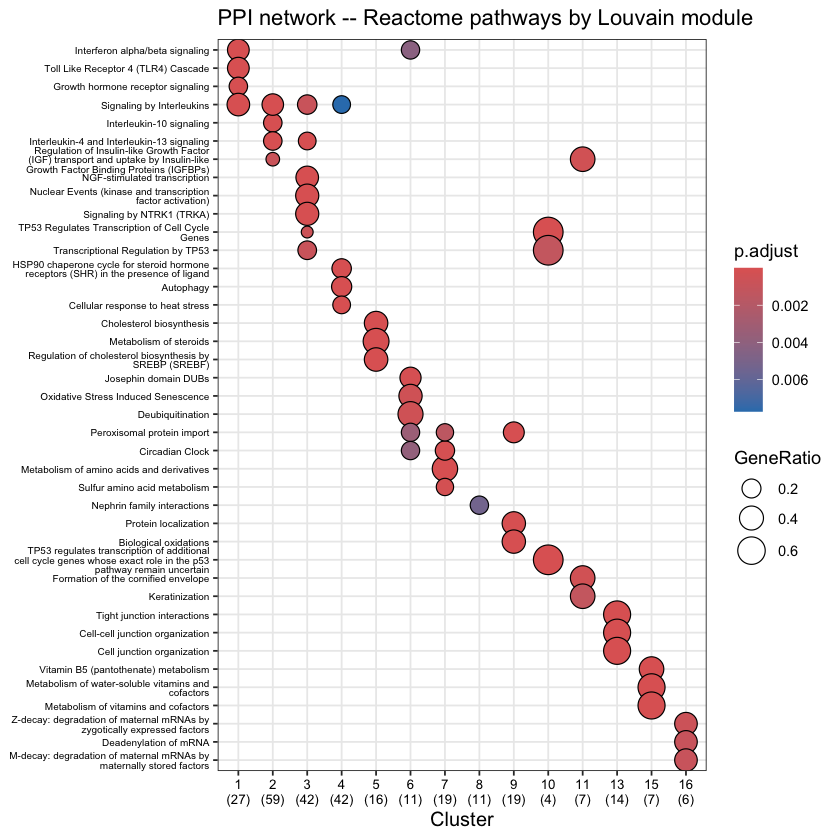

In [38]:
# ============================================================
# 8.5  Functional annotation of PPI modules (Reactome ORA)
# ============================================================
ppi_members <- igraph::membership(ppi_communities)
ppi_module_list <- list()

for (mod in sort(unique(ppi_members))) {
  mod_genes <- names(ppi_members[ppi_members == mod])
  if (length(mod_genes) >= 5) {
    conv <- tryCatch(
      clusterProfiler::bitr(mod_genes, fromType = "SYMBOL", toType = "ENTREZID",
                            OrgDb = org.Hs.eg.db),
      error = function(e) NULL
    )
    if (!is.null(conv) && nrow(conv) > 0) {
      ppi_module_list[[as.character(mod)]] <- conv$ENTREZID
    }
  }
}

cat(sprintf("PPI modules with >= 5 mapped genes: %d\n", length(ppi_module_list)))

if (length(ppi_module_list) > 0) {
  ppi_ora <- clusterProfiler::compareCluster(
    ppi_module_list,
    fun = "enrichPathway",
    organism = "human",
    pvalueCutoff = 0.01
  )
  
  if (nrow(as.data.frame(ppi_ora)) > 0) {
    p_ppi_ora <- clusterProfiler::dotplot(ppi_ora, showCategory = 3) +
      scale_y_discrete(labels = function(x) stringr::str_wrap(x, width = 45)) +
      theme(
        axis.text.y = element_text(size = 6, lineheight = 0.8),
        axis.text.x = element_text(size = 8)
      ) +
      ggtitle("PPI network -- Reactome pathways by Louvain module")
    print(p_ppi_ora)
    ggsave(file.path(OUT_DIR, "bubbleplot_ppi_modules.jpg"), p_ppi_ora,
           width = 14, height = 14, dpi = 300, bg = "white")
    
    # Save pathway results
    write.csv(as.data.frame(ppi_ora),
              file = file.path(OUT_DIR, "pathway_ppi_modules.csv"), row.names = FALSE)
  } else {
    cat("No significantly enriched pathways in PPI modules.\n")
  }
}

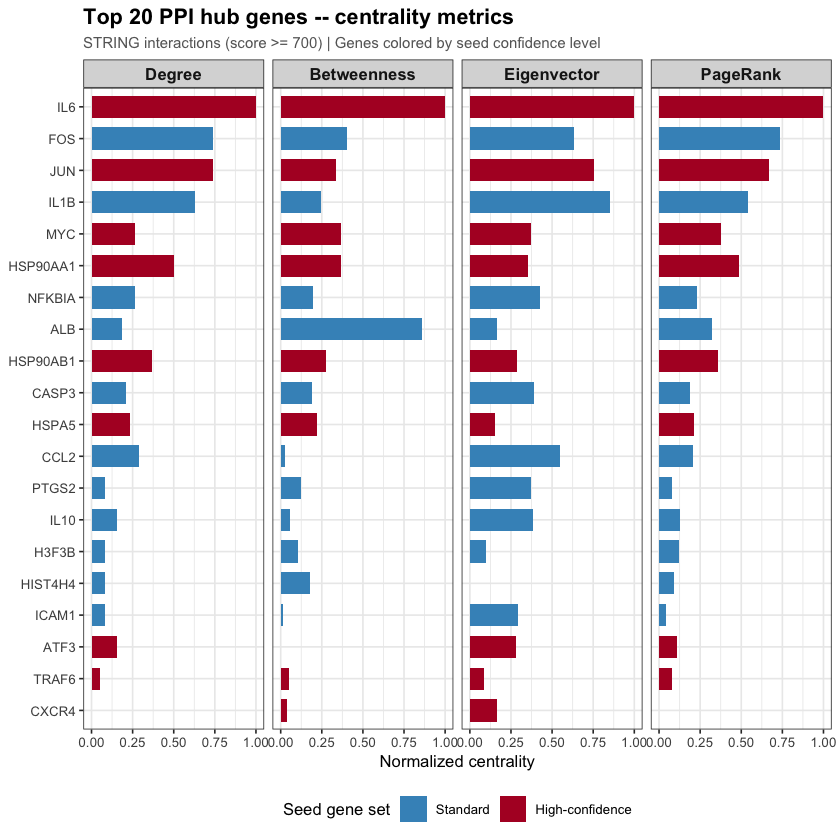

In [39]:
# ============================================================
# 8.6  Hub gene centrality barplot (top 20)
# ============================================================
top20_hubs <- head(centrality_df, 20)
top20_hubs$gene <- factor(top20_hubs$gene, levels = rev(top20_hubs$gene))

# Reshape for faceted barplot
hub_long <- tidyr::pivot_longer(
  top20_hubs,
  cols = c("degree", "betweenness", "eigenvector", "pagerank"),
  names_to = "metric",
  values_to = "value"
)

# Normalize each metric to 0-1 for visual comparison
hub_long <- hub_long %>%
  dplyr::group_by(metric) %>%
  dplyr::mutate(value_norm = (value - min(value)) / (max(value) - min(value) + 1e-10)) %>%
  dplyr::ungroup()

hub_long$metric <- factor(hub_long$metric,
                          levels = c("degree", "betweenness", "eigenvector", "pagerank"),
                          labels = c("Degree", "Betweenness", "Eigenvector", "PageRank"))

p_hubs <- ggplot(hub_long, aes(x = value_norm, y = gene, fill = high_confidence)) +
  geom_bar(stat = "identity", width = 0.7) +
  facet_wrap(~ metric, nrow = 1) +
  scale_fill_manual(
    values = c("TRUE" = "#B2182B", "FALSE" = "#4393C3"),
    labels = c("TRUE" = "High-confidence", "FALSE" = "Standard"),
    name = "Seed gene set"
  ) +
  labs(
    x = "Normalized centrality",
    y = NULL,
    title = "Top 20 PPI hub genes -- centrality metrics",
    subtitle = "STRING interactions (score >= 700) | Genes colored by seed confidence level"
  ) +
  theme_bw(base_size = 10) +
  theme(
    plot.title = element_text(size = 13, face = "bold"),
    plot.subtitle = element_text(size = 9, color = "grey40"),
    strip.text = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 8),
    legend.position = "bottom"
  )

print(p_hubs)
ggsave(file.path(OUT_DIR, "ppi_hub_genes_centrality.jpg"), p_hubs,
       width = 12, height = 7, dpi = 300, bg = "white")

In [40]:
# ============================================================
# 8.7  Convergence: co-expression hubs vs PPI hubs
#      Genes identified by both approaches have highest confidence
# ============================================================

# Top 50 from each approach
coexpr_top50 <- head(hub_genes_iri, 50)
ppi_top50    <- head(centrality_df$gene, 50)

convergent_genes <- intersect(coexpr_top50, ppi_top50)

cat(sprintf("=== Convergence analysis ===\n"))
cat(sprintf("Co-expression hub top-50: %d genes\n", length(coexpr_top50)))
cat(sprintf("PPI hub top-50: %d genes\n", length(ppi_top50)))
cat(sprintf("Overlap: %d genes\n", length(convergent_genes)))

if (length(convergent_genes) > 0) {
  cat("\nConvergent hub genes (co-expression AND PPI):\n")
  cat(paste(convergent_genes, collapse = ", "), "\n")
}

# Fisher exact test for overlap significance
all_genes_in_both <- intersect(
  igraph::V(net_43974_iri$graph)$name,
  igraph::V(ppi_graph_cc)$name
)
n_universe <- length(all_genes_in_both)

a <- length(convergent_genes)
b <- length(setdiff(coexpr_top50, ppi_top50))
c <- length(setdiff(ppi_top50, coexpr_top50))
d <- n_universe - a - b - c

fisher_convergence <- fisher.test(
  matrix(c(a, b, c, d), nrow = 2),
  alternative = "greater"
)

cat(sprintf("\nFisher exact test: OR=%.2f, p=%.2e\n",
            fisher_convergence$estimate, fisher_convergence$p.value))

# Jaccard index
jaccard_conv <- a / (a + b + c)
cat(sprintf("Jaccard index: %.4f\n", jaccard_conv))

ERROR: Error in h(simpleError(msg, call)): errore durante la valutazione dell'argomento 'x' nella selezione di un metodo per la funzione 'head': oggetto 'hub_genes_iri' non trovato


si installano anche le dipendenze 'admisc', 'venn'





I pacchetti binari scaricati sono in
	/var/folders/vw/pn35fz694c583f3r1472jhdc0000gn/T//RtmpYw7OM6/downloaded_packages



Caricamento pacchetto: 'ggVennDiagram'


Il seguente oggetto `e mascherato da 'package:tidyr':

    unite




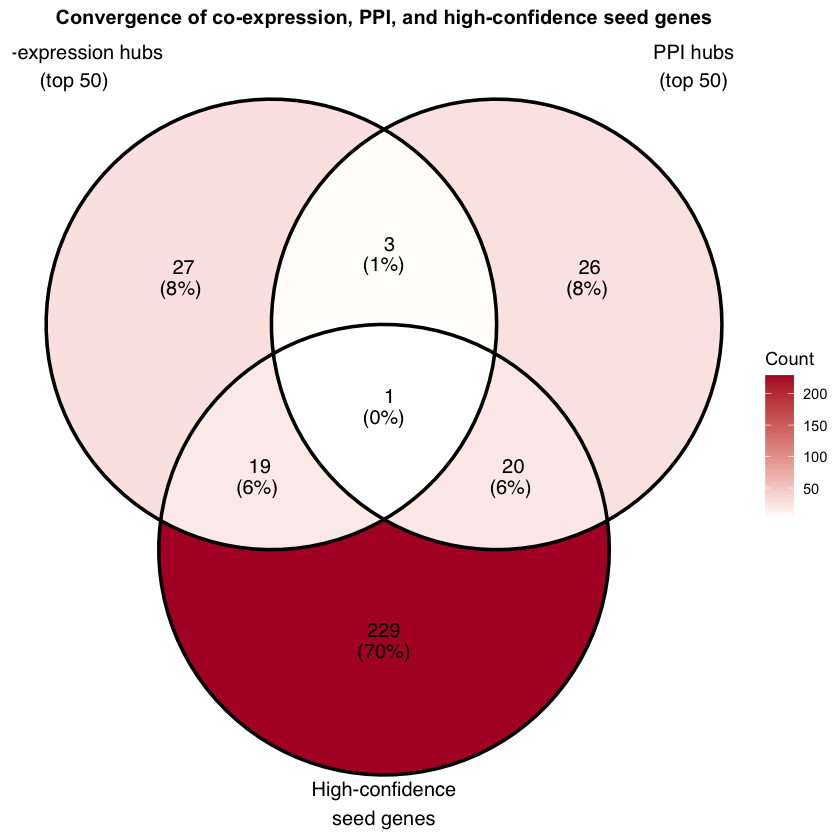

In [ ]:
# ============================================================
# 8.8  Convergence Venn diagram
# ============================================================
if (!requireNamespace("ggVennDiagram", quietly = TRUE)) {
  install.packages("ggVennDiagram")
}
library(ggVennDiagram)

venn_list <- list(
  "Co-expression hubs\n(top 50)" = coexpr_top50,
  "PPI hubs\n(top 50)"           = ppi_top50,
  "High-confidence\nseed genes"   = seed_genes_hc$gene
)

p_venn <- ggVennDiagram(venn_list, label_alpha = 0) +
  scale_fill_gradient(low = "white", high = "#B2182B", name = "Count") +
  ggtitle("Convergence of co-expression, PPI, and high-confidence seed genes") +
  theme(
    plot.title = element_text(size = 12, face = "bold", hjust = 0.5)
  )

print(p_venn)
ggsave(file.path(OUT_DIR, "venn_convergence.jpg"), p_venn,
       width = 8, height = 6, dpi = 300, bg = "white")

In [ ]:
# ============================================================
# 8.9  Save PPI results and final convergent gene list
# ============================================================

# Save PPI network
saveRDS(ppi_graph_cc, file.path(OUT_DIR, "ppi_network.rds"))

# Priority target list: genes in top 50 of BOTH co-expression and PPI
if (length(convergent_genes) > 0) {
  priority_targets <- centrality_df %>%
    dplyr::filter(gene %in% convergent_genes) %>%
    dplyr::left_join(
      seed_genes[, c("gene", "weighted_lfc", "direction_consistency")],
      by = "gene"
    ) %>%
    dplyr::arrange(hub_score)
  
  write.csv(priority_targets, file = file.path(OUT_DIR, "priority_targets_convergent.csv"),
            row.names = FALSE)
  
  cat("Priority target genes (convergent hubs):\n")
  print(priority_targets[, c("gene", "degree", "betweenness", "pagerank",
                             "weighted_lfc", "high_confidence")])
} else {
  cat("No convergent genes between co-expression and PPI top-50 hubs.\n")
  cat("Consider expanding to top-100 or using a lower STRING score threshold.\n")
}

cat(sprintf("\nPPI analysis results saved in: %s\n", OUT_DIR))

Priority target genes (convergent hubs):
    gene degree betweenness    pagerank weighted_lfc high_confidence
1 NFKBIA     29  0.05812149 0.009402603     1.129923           FALSE
2  CEBPB     20  0.01168803 0.006407427     1.331541           FALSE
3    AGT     13  0.02085784 0.004965395     1.112436            TRUE
4   IRF1     14  0.01291705 0.004804943     2.140174           FALSE

PPI analysis results saved in: ../output/fase2


## 9. Summary and publication-ready figures

In [ ]:
# ============================================================
# 9.1  Hub genes and convergence with seed genes
# ============================================================
hub_genes_iri <- get_ranked_gene_list(
  iGraph = net_43974_iri$graph,
  rank_list_attr = c("betweenness", "degree", "closeness", "eigenvector")
)

cat("Top 20 hub genes in IRI network (GSE43974):\n")
print(head(hub_genes_iri, 20))

# Convergence: hub genes also in high-confidence seed set
hub_top50 <- head(hub_genes_iri, 50)
convergence_hc <- intersect(hub_top50, seed_genes_hc$gene)
cat(sprintf("\nConvergence hub top-50 & seed HC: %d genes\n", length(convergence_hc)))
if (length(convergence_hc) > 0) cat(paste(convergence_hc, collapse = ", "), "\n")

Top 20 hub genes in IRI network (GSE43974):
 [1] "MME"       "NPHS2"     "TNFRSF10B" "ADAMTS1"   "UPB1"      "SLC22A8"  
 [7] "SERTAD1"   "SLC47A2"   "GLYAT"     "PRODH2"    "SLC36A2"   "ALAD"     
[13] "PPRC1"     "ELF3"      "DHRS4L2"   "TSPAN6"    "MIDN"      "KCNJ15"   
[19] "GALM"      "DUSP5"    

Convergence hub top-50 & seed HC: 20 genes
TNFRSF10B, ADAMTS1, SLC47A2, PPRC1, TSPAN6, DUSP5, IFRD1, HAVCR2, HBEGF, RHPN2, NAMPT, TKT, UNC5CL, SERTAD4, CTSA, CLDN19, SLC14A1, SGK1, SSPN, AGT 


In [ ]:
# ============================================================
# 9.2  Final summary
# ============================================================
cat("============================================================\n")
cat("       MAGIC SOLUTION -- Phase 2: Summary\n")
cat("============================================================\n\n")

cat(sprintf("Cat. A datasets: %d (meta-analysis) | Cat. B: %d (validation)\n",
            length(de_cat_a), length(de_cat_b)))
cat(sprintf("Genes in meta-analysis: %d\n", nrow(meta_rank)))
cat(sprintf("GSEA-based threshold: top %d genes\n", threshold))
cat(sprintf("\nSeed genes (|lfc|>0.379, consist.>0.5): %d (UP: %d, DOWN: %d)\n",
            nrow(seed_genes), sum(seed_genes$weighted_lfc > 0), sum(seed_genes$weighted_lfc < 0)))
cat(sprintf("Seed genes HIGH-CONFIDENCE (consist.=1.0): %d (UP: %d, DOWN: %d)\n",
            nrow(seed_genes_hc), sum(seed_genes_hc$weighted_lfc > 0), sum(seed_genes_hc$weighted_lfc < 0)))

cat(sprintf("\nCat. B validation (GSE54888):\n"))
cat(sprintf("  Full set:  NES=%.3f, p=%.2e (n=%d)\n", val_full$NES, val_full$pval, val_full$size))
cat(sprintf("  HC set:    NES=%.3f, p=%.2e (n=%d)\n", val_hc$NES, val_hc$pval, val_hc$size))

cat(sprintf("\nCo-expression networks:\n"))
cat(sprintf("  GSE43974 (micro)    IRI: %d nodes, %d edges, %d modules\n",
            vcount(net_43974_iri$graph), ecount(net_43974_iri$graph),
            length(unique(membership(modules_43974_iri)))))
cat(sprintf("  GSE43974 (micro)    Ctrl: %d nodes, %d edges, %d modules\n",
            vcount(net_43974_ctrl$graph), ecount(net_43974_ctrl$graph),
            length(unique(membership(modules_43974_ctrl)))))
cat(sprintf("  GSE126805 (RNA-seq) IRI: %d nodes, %d edges, %d modules\n",
            vcount(net_126805_iri$graph), ecount(net_126805_iri$graph),
            length(unique(membership(modules_126805_iri)))))
cat(sprintf("  GSE126805 (RNA-seq) Ctrl: %d nodes, %d edges, %d modules\n",
            vcount(net_126805_ctrl$graph), ecount(net_126805_ctrl$graph),
            length(unique(membership(modules_126805_ctrl)))))

cat(sprintf("\nLate integration (NMF):\n"))
cat(sprintf("  IRI:  %d aggregated communities\n", n_agg_iri))
cat(sprintf("  Ctrl: %d aggregated communities\n", n_agg_ctrl))

cat(sprintf("\nESEA: %d IRI pathways, %d Ctrl pathways (FDR<0.05)\n",
            sum(esea_iri_pos$FDR_qval < 0.05),
            sum(esea_ctrl_pos$FDR_qval < 0.05)))

cat(sprintf("\nPPI network (STRINGdb, score >= 700):\n"))
cat(sprintf("  Mapped genes: %d / %d\n", nrow(seed_mapped), nrow(seed_genes)))
cat(sprintf("  Largest component: %d nodes, %d edges\n",
            vcount(ppi_graph_cc), ecount(ppi_graph_cc)))
cat(sprintf("  Louvain modules: %d (modularity=%.3f)\n",
            length(unique(membership(ppi_communities))), modularity(ppi_communities)))

cat(sprintf("\nConvergence (co-expression & PPI top-50 hubs):\n"))
cat(sprintf("  Overlap: %d genes\n", length(convergent_genes)))
cat(sprintf("  Fisher p=%.2e, Jaccard=%.4f\n", fisher_convergence$p.value, jaccard_conv))
if (length(convergent_genes) > 0) {
  cat(sprintf("  Priority targets: %s\n", paste(convergent_genes, collapse = ", ")))
}

cat("\n============================================================\n")
cat("Output saved in:", OUT_DIR, "\n")
cat("============================================================\n")

       MAGIC SOLUTION -- Phase 2: Summary

Cat. A datasets: 3 (meta-analysis) | Cat. B: 1 (validation)
Genes in meta-analysis: 12127
GSEA-based threshold: top 1420 genes

Seed genes (|lfc|>0.379, consist.>0.5): 650 (UP: 544, DOWN: 106)
Seed genes HIGH-CONFIDENCE (consist.=1.0): 269 (UP: 229, DOWN: 40)

Cat. B validation (GSE54888):
  Full set:  NES=1.731, p=9.41e-11 (n=636)
  HC set:    NES=2.385, p=2.63e-18 (n=266)

Co-expression networks:
  GSE43974 (micro)    IRI: 650 nodes, 4229 edges, 11 modules
  GSE43974 (micro)    Ctrl: 650 nodes, 4631 edges, 20 modules
  GSE126805 (RNA-seq) IRI: 650 nodes, 4646 edges, 9 modules
  GSE126805 (RNA-seq) Ctrl: 650 nodes, 4157 edges, 11 modules

Late integration (NMF):
  IRI:  10 aggregated communities
  Ctrl: 16 aggregated communities

ESEA: 0 IRI pathways, 0 Ctrl pathways (FDR<0.05)



PPI network (STRINGdb, score >= 700):
  Mapped genes: 639 / 650
  Largest component: 345 nodes, 1112 edges
  Louvain modules: 16 (modularity=0.637)

Convergence (co-expression & PPI top-50 hubs):
  Overlap: 4 genes
  Fisher p=9.57e-01, Jaccard=0.0417
  Priority targets: IRF1, NFKBIA, CEBPB, AGT

Output saved in: ../output/fase2 


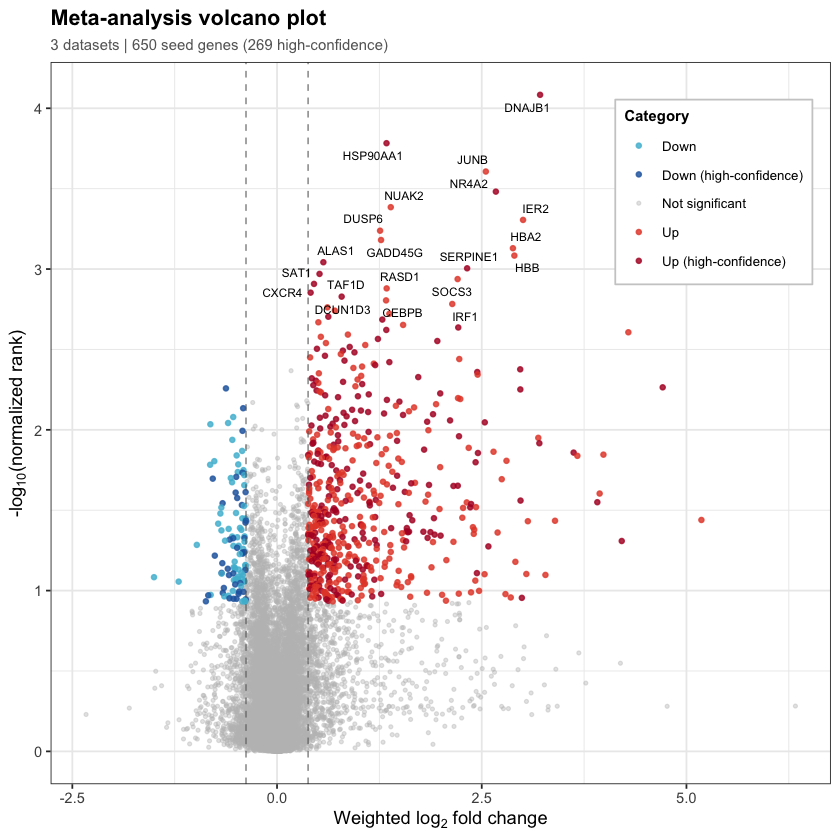

In [ ]:
# ============================================================
# 9.3  Volcano plot of meta-analysis results
# ============================================================
volcano_df <- meta_rank %>%
  dplyr::filter(!is.na(weighted_lfc), !is.na(direction_consistency)) %>%
  dplyr::mutate(
    neg_log10_rank = -log10(rank / max(rank)),
    category = case_when(
      gene %in% seed_genes_hc$gene & weighted_lfc > 0 ~ "Up (high-confidence)",
      gene %in% seed_genes_hc$gene & weighted_lfc < 0 ~ "Down (high-confidence)",
      gene %in% seed_genes$gene & weighted_lfc > 0    ~ "Up",
      gene %in% seed_genes$gene & weighted_lfc < 0    ~ "Down",
      TRUE ~ "Not significant"
    )
  )

top_labels <- volcano_df %>%
  dplyr::filter(category != "Not significant") %>%
  dplyr::arrange(rank) %>%
  dplyr::slice_head(n = 20)

p_volcano <- ggplot(volcano_df, aes(x = weighted_lfc, y = neg_log10_rank, color = category)) +
  geom_point(alpha = 0.4, size = 0.8) +
  geom_point(data = volcano_df %>% filter(category != "Not significant"),
             alpha = 0.7, size = 1.2) +
  scale_color_manual(
    values = c("Not significant" = "grey75",
               "Up" = "#E64B35",
               "Down" = "#4DBBD5",
               "Up (high-confidence)" = "#B2182B",
               "Down (high-confidence)" = "#2166AC"),
    name = "Category"
  ) +
  geom_vline(xintercept = c(-0.379, 0.379), linetype = "dashed", color = "grey40", linewidth = 0.3) +
  ggrepel::geom_text_repel(
    data = top_labels, aes(label = gene),
    size = 2.5, max.overlaps = 20, segment.size = 0.2, color = "black"
  ) +
  labs(
    x = expression("Weighted log"[2]*" fold change"),
    y = expression("-log"[10]*"(normalized rank)"),
    title = "Meta-analysis volcano plot",
    subtitle = sprintf("3 datasets | %d seed genes (%d high-confidence)", nrow(seed_genes), nrow(seed_genes_hc))
  ) +
  theme_bw(base_size = 11) +
  theme(
    legend.position = c(0.85, 0.82),
    legend.background = element_rect(fill = "white", color = "grey80"),
    legend.text = element_text(size = 8),
    legend.title = element_text(size = 9, face = "bold"),
    plot.title = element_text(size = 13, face = "bold"),
    plot.subtitle = element_text(size = 9, color = "grey40")
  )

print(p_volcano)
ggsave(file.path(OUT_DIR, "volcano_meta_analysis.jpg"), p_volcano,
       width = 7, height = 5.5, dpi = 300, bg = "white")

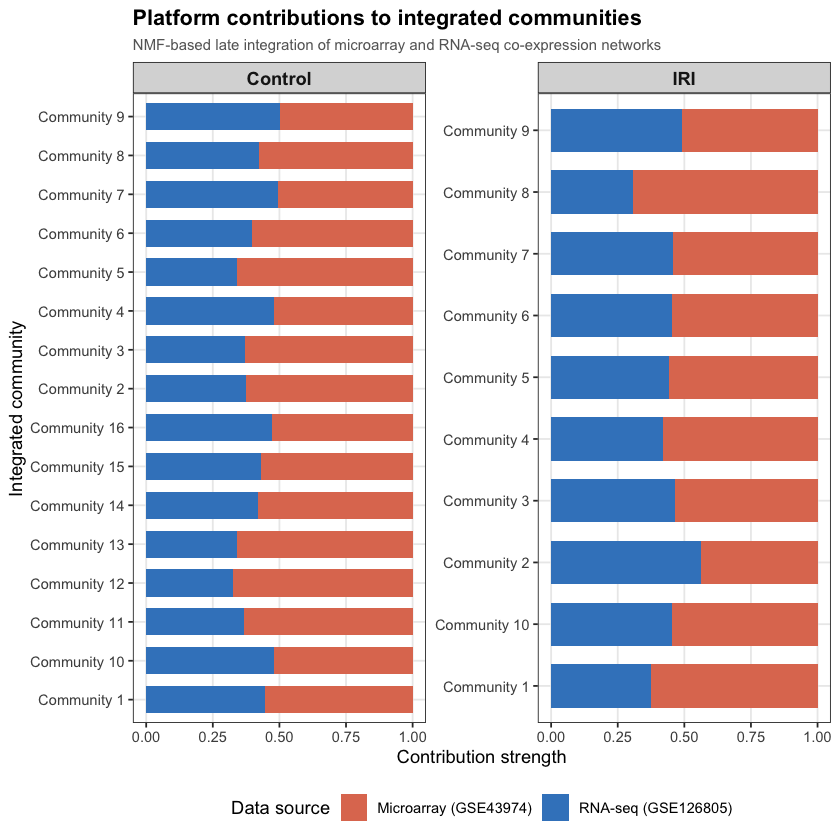

In [ ]:
# ============================================================
# 9.4  Platform contribution barplot (late integration)
# ============================================================
build_contrib_df <- function(agg_result, condition_label) {
  contrib <- agg_result$view_contributions
  df <- as.data.frame(contrib)
  df$platform <- rownames(df)
  df_long <- tidyr::pivot_longer(df, cols = -platform, names_to = "community", values_to = "contribution")
  df_long$community <- gsub("V", "Community ", df_long$community)
  df_long$condition <- condition_label
  df_long$platform <- ifelse(df_long$platform == "micro", "Microarray (GSE43974)", "RNA-seq (GSE126805)")
  df_long
}

contrib_df <- rbind(
  build_contrib_df(agg_iri, "IRI"),
  build_contrib_df(agg_ctrl, "Control")
)

p_contrib <- ggplot(contrib_df, aes(x = contribution, y = community, fill = platform)) +
  geom_bar(stat = "identity", position = "stack", width = 0.7) +
  facet_wrap(~ condition, scales = "free_y") +
  scale_fill_manual(
    values = c("Microarray (GSE43974)" = "#E07A5F", "RNA-seq (GSE126805)" = "#3D85C6"),
    name = "Data source"
  ) +
  labs(
    x = "Contribution strength",
    y = "Integrated community",
    title = "Platform contributions to integrated communities",
    subtitle = "NMF-based late integration of microarray and RNA-seq co-expression networks"
  ) +
  theme_bw(base_size = 11) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(size = 11, face = "bold"),
    plot.title = element_text(size = 13, face = "bold"),
    plot.subtitle = element_text(size = 9, color = "grey40"),
    panel.grid.minor = element_blank()
  )

print(p_contrib)
ggsave(file.path(OUT_DIR, "platform_contributions.jpg"), p_contrib,
       width = 9, height = 5, dpi = 300, bg = "white")

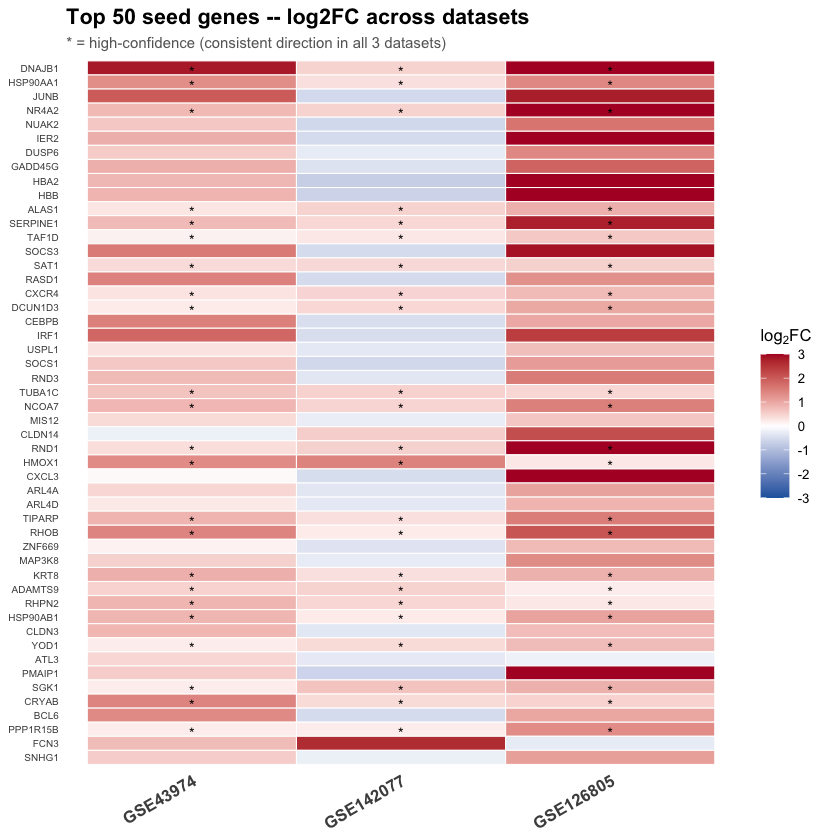

In [ ]:
# ============================================================
# 9.5  Heatmap of log2FC consistency across datasets
# ============================================================
top_n <- 50
top_seeds <- seed_genes %>% dplyr::slice_head(n = top_n)

lfc_for_heatmap <- lapply(names(de_cat_a), function(id) {
  d <- de_cat_a[[id]] %>%
    dplyr::select(gene, log2FoldChange) %>%
    dplyr::distinct(gene, .keep_all = TRUE)
  colnames(d)[2] <- id
  d
})

hm_df <- lfc_for_heatmap[[1]]
for (i in 2:length(lfc_for_heatmap)) {
  hm_df <- merge(hm_df, lfc_for_heatmap[[i]], by = "gene", all = FALSE)
}

hm_df <- hm_df %>% dplyr::filter(gene %in% top_seeds$gene)
rownames(hm_df) <- hm_df$gene
hm_mat <- as.matrix(hm_df[, -1])

gene_order <- top_seeds$gene[top_seeds$gene %in% rownames(hm_mat)]
hm_mat <- hm_mat[gene_order, ]

hm_long <- reshape2::melt(hm_mat)
colnames(hm_long) <- c("Gene", "Dataset", "log2FC")
hm_long$log2FC_trunc <- pmax(pmin(hm_long$log2FC, 3), -3)
hm_long$HC <- ifelse(hm_long$Gene %in% seed_genes_hc$gene, "*", "")

p_heatmap <- ggplot(hm_long, aes(x = Dataset, y = Gene, fill = log2FC_trunc)) +
  geom_tile(color = "white", linewidth = 0.3) +
  geom_text(aes(label = HC), size = 3, color = "black", vjust = 0.8) +
  scale_fill_gradient2(
    low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0,
    limits = c(-3, 3), name = expression("log"[2]*"FC"),
    oob = scales::squish
  ) +
  scale_y_discrete(limits = rev(gene_order)) +
  labs(
    x = NULL,
    y = NULL,
    title = sprintf("Top %d seed genes -- log2FC across datasets", top_n),
    subtitle = "* = high-confidence (consistent direction in all 3 datasets)"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 6, face = "plain"),
    axis.text.x = element_text(size = 10, angle = 30, hjust = 1, face = "bold"),
    plot.title = element_text(size = 13, face = "bold"),
    plot.subtitle = element_text(size = 9, color = "grey40"),
    legend.position = "right",
    panel.grid = element_blank()
  )

print(p_heatmap)
ggsave(file.path(OUT_DIR, "heatmap_top_seed_genes.jpg"), p_heatmap,
       width = 5, height = 10, dpi = 300, bg = "white")

In [ ]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-apple-darwin20
Running under: macOS Monterey 12.7.6

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/Rome
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggVennDiagram_1.5.7    STRINGdb_2.18.0        msigdbr_26.1.0        
 [4] igraph_2.2.3           fgsea_1.32.4           org.Hs.eg.db_3.20.0   
 [7] AnnotationDbi_1.68.0   IRanges_2.40.1         S4Vectors_0.44.0      
[10] Biobase_2.66.0         BiocGenerics_0.52.0    ReactomePA_1.50.0     
[13] clusterProfiler_4.14.6 ggplot2_4.0.2          tidyr_1.3.2           
[16] dplyr_1.2.1            muumi_0.0.0.9000      

loaded via a namespace (and not attached):
  